# 2026 CITS4012 Project
*Make sure you change the file name with your group id.*

# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

**Group 69: PIQA / DACT. Reproduction candidate with improved evidence retention.**

This generated notebook has no full experimental outputs until executed. The historical executed
submission candidate is `CITS4012_69.ipynb`. Do not mix their outputs.

1. Select a Colab GPU. The original full run used an A100 40 GB. Smaller GPUs may need separately logged
   resource settings; the original B4 batch size is not guaranteed to fit every GPU.
2. Place the supplied ZIP at `MyDrive/Group69/PIQA.zip`, or place its four files under `data/piqa/`.
3. Run all. The setup cell checks/imports dependencies and installs missing ones. Exact historical
   versions are recorded in the historical notebook and `requirements-a100.txt`.
4. Results go to a fresh timestamped output directory; checkpoints and prediction rows are retained.
   Download that directory before ending the runtime. The last cell copies it to Drive when mounted.

DACT uses no pretrained weights or external corpus. B3/B4 are explicitly pretrained baselines.
All model selection uses validation. The existing split is preserved, including the disclosed
training/test duplicate; new results must retain this limitation. The test set is not an unseen benchmark
for any design revisions after the historical analysis. `symmetric_diff_tags=False` preserves historical
alignment; changing it is a separately labelled experimental protocol, not a reproduction.

For an offline development check set `PIQA_SMOKE=1` before running. It uses tiny training/validation
subsets, a validation-derived diagnostic holdout, one seed/epoch, and **skips B3/B4**. Its displayed
metrics and figures are diagnostic artifacts, never reportable full PIQA test results.

# 1.Dataset Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 1.1 Environment check and configuration
All hyper-parameters live in one `Config` dataclass so that every experiment (including ablations) is a documented, logged variation of it.

In [ ]:
import os, sys, platform, importlib, subprocess
SMOKE = os.environ.get("PIQA_SMOKE") == "1"
packages = {"torch":"torch==2.11.0", "numpy":"numpy", "sklearn":"scikit-learn",
            "scipy":"scipy", "pandas":"pandas", "matplotlib":"matplotlib", "tokenizers":"tokenizers"}
if not SMOKE:
    packages["transformers"] = "transformers==5.16.1"
for package, requirement in packages.items():
    try:
        imported = importlib.import_module(package)
    except ImportError:
        subprocess.check_call([sys.executable,"-m","pip","install",requirement])
        imported = importlib.import_module(package)
    print(f"{package:13s}", imported.__version__)
import torch
print("python",platform.python_version())
print("GPU",torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("MODE:","DEVELOPMENT ONLY; pretrained baselines skipped" if SMOKE else "FULL REPRODUCTION")

torch         2.11.0+cu128
numpy         2.1.3


sklearn       1.6.1
scipy         1.16.3
pandas        2.2.3
matplotlib    3.10.0
tokenizers    0.23.1


transformers  5.16.1
python 3.13.15
GPU NVIDIA A100-SXM4-40GB
MODE: FULL REPRODUCTION


In [ ]:
"""Global configuration, reproducibility and device helpers."""
import json
import os
import random
import time
import platform
import importlib.metadata
from dataclasses import asdict, dataclass, replace

import numpy as np
import torch


@dataclass
class Config:
    # ---- paths ----
    drive_zip: str = "/content/drive/MyDrive/Group69/PIQA.zip"  # Colab location of the provided data
    local_zip_glob: str = "*.zip"                               # fallback when running outside Colab
    data_dir: str = "data/piqa"
    out_dir: str = "outputs"

    # ---- data ----
    seed: int = 42              # seed for the train/validation split (kept fixed across runs)
    val_frac: float = 0.10
    vocab_size: int = 8000
    min_frequency: int = 2
    max_goal_len: int = 40      # BPE tokens
    max_sol_len: int = 96

    # ---- model (DACT) ----
    d_model: int = 256
    n_heads: int = 4
    n_layers: int = 4
    d_ff: int = 1024
    dropout: float = 0.2
    attn_dropout: float = 0.1
    max_len: int = 160

    # ---- ablation switches ----
    use_diff_tags: bool = True        # difference-tag embedding
    use_cross_solution: bool = True   # sol1 <-> sol2 contrastive cross-attention
    pool_mode: str = "diff_attn"      # "diff_attn" | "attn" | "mean"
    objective: str = "pairwise"       # "pairwise" (softmax over the two options) | "pointwise" (independent BCE)
    mlm_epochs: int = 0               # in-domain masked-LM warm-up on the training split only

    # ---- optimisation ----
    batch_size: int = 128
    lr: float = 3e-4
    weight_decay: float = 0.05
    epochs: int = 20
    warmup_ratio: float = 0.06
    label_smoothing: float = 0.1
    patience: int = 6
    grad_clip: float = 1.0
    mlm_lr: float = 5e-4
    mlm_prob: float = 0.15
    amp: bool = True
    num_workers: int = 2
    run_seed: int = 42         # model/data-loader RNG; seed above remains the fixed split seed
    deterministic: bool = False  # historical CUDA runs used fast, nondeterministic kernels
    symmetric_diff_tags: bool = False  # opt-in NEW protocol; historical results use False

    def to_dict(self):
        return asdict(self)

    def but(self, **kw):
        """Return a copy with some fields overridden (used for ablations / seeds)."""
        return replace(self, **kw)


def set_seed(seed: int, deterministic=False):
    if deterministic:
        os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(deterministic)
    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cudnn.benchmark = not deterministic


def environment_info(device=None):
    """Runtime provenance; recorded values describe this run, never the historical run."""
    versions = {}
    for package in ("torch", "numpy", "scikit-learn", "scipy", "pandas", "matplotlib", "tokenizers", "transformers"):
        try:
            versions[package] = importlib.metadata.version(package)
        except importlib.metadata.PackageNotFoundError:
            versions[package] = None
    return {"python": platform.python_version(), "platform": platform.platform(), "packages": versions,
            "device": str(device), "cuda": torch.version.cuda,
            "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
            "deterministic": torch.are_deterministic_algorithms_enabled()}


def get_device():
    if torch.cuda.is_available():
        # TF32 matmuls: large speed-up on Ampere+ GPUs (A100 / L4) with negligible accuracy impact
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = not torch.are_deterministic_algorithms_enabled()
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def amp_dtype(device):
    """bf16 autocast on GPUs that support it, fp16 on older CUDA GPUs, disabled elsewhere."""
    if device.type != "cuda":
        return None
    return torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16


class JsonlLogger:
    """Append-only JSON-lines logger so every training/evaluation run leaves a persistent log file."""

    def __init__(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        self.path = path

    def log(self, **record):
        record = {"time": time.strftime("%Y-%m-%d %H:%M:%S"), **record}
        with open(self.path, "a", encoding="utf-8") as f:
            f.write(json.dumps(record) + "\n")
        return record

In [ ]:
import time
CFG = Config(data_dir=os.environ.get("PIQA_DATA_DIR", "data/piqa"),
             out_dir="experiments/" + ("development/" if SMOKE else "completed/") + "outputs_reproduction_" + time.strftime("%Y%m%d_%H%M%S"))
if SMOKE:
    CFG = CFG.but(epochs=1, d_model=64, d_ff=128, n_layers=2, batch_size=32, num_workers=0)
DEVICE = get_device()
set_seed(CFG.run_seed, CFG.deterministic)
os.makedirs(CFG.out_dir, exist_ok=False)
print("device:",DEVICE,"| output:",CFG.out_dir)

device: cuda | output: experiments/completed/outputs_reproduction_20261001_161337


## 1.2 Loading, splitting and tokenising PIQA
* Each item: a **goal** and two candidate **solutions**; the label says which solution is physically sensible.
* The provided `test` split (1,838 items) is reserved for final model inference in this reproduction; a stratified 10 % of the training file is held out as the **validation** split.
* **Tokenizer:** byte-pair encoding (8,000-entry vocabulary) *learned on the training split only*. PIQA has many rare, domain-specific words (tools, materials, recipes), so sub-words avoid a large `[UNK]` rate that a word-level vocabulary would have.
* **Difference tags:** the two solutions of an item are usually near-duplicates. We align their BPE sequences with `difflib.SequenceMatcher` and tag every solution token as *shared* or *different*. These tags are consumed by the model (Section 2).

In [ ]:
"""PIQA loading, train/validation split, BPE tokenizer, difference tags and batching."""
import difflib
import glob
import json
import os
import zipfile
import hashlib

import numpy as np
import torch
from sklearn.model_selection import train_test_split
from tokenizers import Tokenizer, models, normalizers, pre_tokenizers, trainers
from torch.utils.data import DataLoader, Dataset


EXPECTED_FILES = ("train.jsonl", "train-labels.lst", "test.jsonl", "test-labels.lst")
SPECIALS = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
PAD, UNK, CLS, SEP, MASK = range(len(SPECIALS))

# difference-tag vocabulary
TAG_OTHER, TAG_SHARED, TAG_DIFF = 0, 1, 2   # goal/special tokens, token shared by both solutions, token unique to this solution


# ----------------------------------------------------------------------------------------------
# 1. Locating and extracting the data
# ----------------------------------------------------------------------------------------------
def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _find_zip(cfg: Config):
    if _in_colab():
        from google.colab import drive
        if not os.path.isdir("/content/drive/MyDrive"):
            drive.mount("/content/drive")
        if os.path.isfile(cfg.drive_zip):
            return cfg.drive_zip
        raise FileNotFoundError(f"PIQA zip not found at {cfg.drive_zip}. Update Config.drive_zip.")
    for path in [cfg.drive_zip, *sorted(glob.glob(cfg.local_zip_glob))]:
        if os.path.isfile(path) and zipfile.is_zipfile(path):
            with zipfile.ZipFile(path) as zf:
                names = {os.path.basename(n) for n in zf.namelist()}
            if set(EXPECTED_FILES) <= names:
                return path
    raise FileNotFoundError("No zip containing the PIQA files was found.")


def prepare_data(cfg: Config):
    """Extract only the four expected PIQA files into cfg.data_dir (no arbitrary paths are written)."""
    if all(os.path.isfile(os.path.join(cfg.data_dir, f)) for f in EXPECTED_FILES):
        return cfg.data_dir
    zpath = _find_zip(cfg)
    os.makedirs(cfg.data_dir, exist_ok=True)
    with zipfile.ZipFile(zpath) as zf:
        members = {os.path.basename(n): n for n in zf.namelist() if not n.endswith("/")}
        for fname in EXPECTED_FILES:
            with zf.open(members[fname]) as src, open(os.path.join(cfg.data_dir, fname), "wb") as dst:
                dst.write(src.read())
    print(f"Extracted {EXPECTED_FILES} from {zpath} -> {cfg.data_dir}")
    return cfg.data_dir


def load_split(data_dir, split):
    with open(os.path.join(data_dir, f"{split}.jsonl"), encoding="utf-8") as f:
        rows = [json.loads(line) for line in f if line.strip()]
    with open(os.path.join(data_dir, f"{split}-labels.lst"), encoding="utf-8") as f:
        labels = [int(line) for line in f if line.strip()]
    if len(rows) != len(labels):
        raise ValueError(f"{split}: {len(rows)} rows vs {len(labels)} labels")
    for i, (r, y) in enumerate(zip(rows, labels)):
        if y not in (0, 1):
            raise ValueError(f"{split} row {i}: label must be 0 or 1")
        r["label"] = y
        for k in ("goal", "sol1", "sol2"):
            if not isinstance(r.get(k), str) or not r[k].strip():
                raise ValueError(f"{split} row {i}: {k} must be a nonempty string")
            r[k] = " ".join(r[k].split())  # collapse irregular whitespace
    return rows


def load_piqa(cfg: Config):
    """Returns train / validation (held out from the official training file) / test.

    The test split is returned separately and must only be used for the final evaluation.
    """
    data_dir = prepare_data(cfg)
    full_train = load_split(data_dir, "train")
    test = load_split(data_dir, "test")
    idx = np.arange(len(full_train))
    tr_idx, va_idx = train_test_split(idx, test_size=cfg.val_frac, random_state=cfg.seed,
                                      stratify=[r["label"] for r in full_train])
    train = [full_train[i] for i in tr_idx]
    val = [full_train[i] for i in va_idx]
    return train, val, test


# ----------------------------------------------------------------------------------------------
# 2. Tokenizer (BPE learned from the training split only)
# ----------------------------------------------------------------------------------------------
def train_tokenizer(train_rows, cfg: Config, path=None):
    if path and os.path.exists(path):
        raise FileExistsError(f"Tokenizer evidence already exists: {path}. Use a fresh output directory.")
    tok = Tokenizer(models.BPE(unk_token="[UNK]"))
    tok.normalizer = normalizers.Sequence([normalizers.NFKC(), normalizers.Lowercase()])
    tok.pre_tokenizer = pre_tokenizers.Sequence([pre_tokenizers.Whitespace(), pre_tokenizers.Digits(individual_digits=True)])
    trainer = trainers.BpeTrainer(vocab_size=cfg.vocab_size, min_frequency=cfg.min_frequency,
                                  special_tokens=SPECIALS, continuing_subword_prefix="##")
    corpus = (text for r in train_rows for text in (r["goal"], r["sol1"], r["sol2"]))
    tok.train_from_iterator(corpus, trainer=trainer, length=3 * len(train_rows))
    if path:
        os.makedirs(os.path.dirname(path), exist_ok=True)
        tok.save(path)
    return tok


def diff_tags(a, b, symmetric=False):
    """Legacy alignment by default; canonical option order is an opt-in new preprocessing protocol.

    SequenceMatcher tie-breaking is directional. Canonical ordering makes alignment equivariant
    without consulting labels. Historical results must not be attributed to symmetric=True.
    """
    if symmetric and tuple(a) > tuple(b):
        tb, ta = diff_tags(b, a)
        return ta, tb
    ta, tb = [TAG_DIFF] * len(a), [TAG_DIFF] * len(b)
    sm = difflib.SequenceMatcher(None, a, b, autojunk=False)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "equal":
            ta[i1:i2] = [TAG_SHARED] * (i2 - i1)
            tb[j1:j2] = [TAG_SHARED] * (j2 - j1)
    return ta, tb


def encode_example(row, tok, cfg: Config):
    """Encodes one PIQA item into two sequences [CLS] goal [SEP] sol_i [SEP] plus side information."""
    g = tok.encode(row["goal"]).ids[: cfg.max_goal_len]
    s1 = tok.encode(row["sol1"]).ids[: cfg.max_sol_len]
    s2 = tok.encode(row["sol2"]).ids[: cfg.max_sol_len]
    t1, t2 = diff_tags(s1, s2, cfg.symmetric_diff_tags)
    out = []
    for s, t in ((s1, t1), (s2, t2)):
        ids = [CLS] + g + [SEP] + s + [SEP]
        seg = [0] * (len(g) + 2) + [1] * (len(s) + 1)
        tags = [TAG_OTHER] * (len(g) + 2) + t + [TAG_OTHER]
        sol = [0] * (len(g) + 2) + [1] * len(s) + [0]   # positions that belong to the solution text
        out.append((ids, seg, tags, sol))
    return out


class PIQADataset(Dataset):
    """Pre-tokenises everything once so the GPU is not starved by Python-side work."""

    def __init__(self, rows, tok, cfg: Config):
        self.rows = rows
        self.items = [encode_example(r, tok, cfg) for r in rows]
        self.labels = [r["label"] for r in rows]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i], self.labels[i], i


def collate(batch):
    """Pads a batch into tensors of shape [B, 2, L]."""
    B = len(batch)
    L = max(len(seq[0]) for item, _, _ in batch for seq in item)
    ids = torch.full((B, 2, L), PAD, dtype=torch.long)
    seg = torch.zeros((B, 2, L), dtype=torch.long)
    tags = torch.zeros((B, 2, L), dtype=torch.long)
    sol = torch.zeros((B, 2, L), dtype=torch.bool)
    for b, (item, _, _) in enumerate(batch):
        for k, (i_, s_, t_, m_) in enumerate(item):
            n = len(i_)
            ids[b, k, :n] = torch.tensor(i_)
            seg[b, k, :n] = torch.tensor(s_)
            tags[b, k, :n] = torch.tensor(t_)
            sol[b, k, :n] = torch.tensor(m_, dtype=torch.bool)
    return {
        "input_ids": ids, "segment": seg, "tags": tags, "sol_mask": sol,
        "attn_mask": ids != PAD,
        "labels": torch.tensor([y for _, y, _ in batch], dtype=torch.long),
        "index": torch.tensor([i for _, _, i in batch], dtype=torch.long),
    }


def make_loader(ds, cfg: Config, shuffle, device):
    return DataLoader(ds, batch_size=cfg.batch_size, shuffle=shuffle, collate_fn=collate,
                      num_workers=cfg.num_workers if device.type == "cuda" else 0,
                      pin_memory=device.type == "cuda", persistent_workers=False)


def prepare_everything(cfg: Config):
    """Loads the splits, learns the BPE tokenizer on the training split and pre-tokenises every split."""
    train, val, test = load_piqa(cfg)
    tok = train_tokenizer(train, cfg, path=os.path.join(cfg.out_dir, "tokenizer.json"))
    manifest = {"split_seed": cfg.seed, "val_frac": cfg.val_frac, "files": {}, "splits": {}}
    for fname in EXPECTED_FILES:
        with open(os.path.join(cfg.data_dir, fname), "rb") as stream:
            manifest["files"][fname] = hashlib.sha256(stream.read()).hexdigest()
    for name, rows in (("train", train), ("val", val), ("test", test)):
        payload = json.dumps(rows, ensure_ascii=False, sort_keys=True).encode("utf-8")
        manifest["splits"][name] = {"size": len(rows), "ordered_sha256": hashlib.sha256(payload).hexdigest()}
    manifest["tokenizer_sha256"] = hashlib.sha256(tok.to_str().encode("utf-8")).hexdigest()
    with open(os.path.join(cfg.out_dir, "data_manifest.json"), "w", encoding="utf-8") as stream:
        json.dump(manifest, stream, indent=2)
    return {"train": train, "val": val, "test": test, "tok": tok, "vocab_size": tok.get_vocab_size(),
            "train_ds": PIQADataset(train, tok, cfg), "val_ds": PIQADataset(val, tok, cfg),
            "test_ds": PIQADataset(test, tok, cfg)}


def token_strings(tok, ids):
    return [tok.id_to_token(int(i)) for i in ids]

In [ ]:
DATA = prepare_everything(CFG)
if SMOKE:
    # Use validation rows for the diagnostic third split; never infer on official test in smoke mode.
    DATA["train"], DATA["val"], DATA["test"] = DATA["train"][:128], DATA["val"][:128], DATA["val"][128:256]
    for split in ("train","val","test"):
        DATA[f"{split}_ds"] = PIQADataset(DATA[split],DATA["tok"],CFG)
    print("SMOKE: 'test' below is a validation-derived diagnostic holdout, not official test.")
print({s:len(DATA[s]) for s in ("train","val","test")},"| vocab:",DATA["vocab_size"])

{'train': 14501, 'val': 1612, 'test': 1838} | vocab: 8000


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
rows = []
for split in ("train", "val"):  # no test statistics during development
    for field in ("goal","sol1","sol2"):
        lengths = np.array([len(DATA["tok"].encode(r[field]).ids) for r in DATA[split]])
        limit = CFG.max_goal_len if field == "goal" else CFG.max_sol_len
        rows.append({"split":split,"field":field,"items":len(lengths),"mean":lengths.mean(),
                     "median":np.median(lengths),"p95":np.percentile(lengths,95),
                     "p99":np.percentile(lengths,99),"truncated":int((lengths>limit).sum())})
display(pd.DataFrame(rows).round(3))

,split,field,items,mean,median,p95,p99,truncated
0,train,goal,14501,8.299,8.0,16.00,20.00,0
1,train,sol1,14501,22.275,14.0,65.00,108.00,210
2,train,sol2,14501,22.279,14.0,64.00,108.00,216
3,val,goal,1612,8.525,8.0,16.00,21.00,0
4,val,sol1,1612,22.697,15.0,66.00,111.67,21
5,val,sol2,1612,22.722,15.0,65.45,112.00,23


**Length protocol.** These statistics are before truncation. The historical limits
40/96 are retained for reproduction, with acknowledged information loss in long examples. Accuracy is
the number of correctly selected options divided by the number of examples; it directly measures the
two-choice task. Approximate label balance makes chance/majority useful reference points.

# 2. Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 2.1 DACT: Difference-Aware Contrastive Transformer

```
 goal + sol1 ─┐                                     ┌─ diff-guided attention pooling ─┐
              ├─ shared Transformer encoder ─ h1 ─┐ │                                 ├─ scorer → s1 ┐
 tags(sol1)  ─┘   (token+pos+segment+DIFF-TAG)    ├─┤ contrastive cross-solution attn │              ├─ softmax → P(option)
 goal + sol2 ─┐                                   │ │   h_i attends to h_j, fuse      │              │
              ├─ shared Transformer encoder ─ h2 ─┘ │   [h; c; h−c; h⊙c]              ├─ scorer → s2 ┘
 tags(sol2)  ─┘                                     └─────────────────────────────────┘
```

| Component | Standard choice | Our PIQA-specific change | Why |
|---|---|---|---|
| Input embedding | token + position (+ segment) | **+ difference-tag embedding** (goal/special, shared, different) | Tells the encoder from layer 1 where the two options disagree, so it does not have to learn this from 14.5k items |
| Option interaction | options scored independently | **Contrastive cross-solution attention**: each token of option *i* attends to the tokens of option *j* (plus a `[CLS]` sink for "no counterpart"), fused ESIM-style with `[h; c; h−c; h⊙c]` | Physical plausibility is relative ("jar" vs "plate"); the comparison features encode what replaced what |
| Summary vector | `[CLS]` or mean pooling | **Difference-guided additive attention pooling** with a learned bias per tag | Puts the decision on the few decisive tokens while the pooling weights remain interpretable |
| Objective | independent binary classification | **Pairwise softmax** over the two option scores (label smoothing 0.1) | Matches the forced-choice task |
| Encoder | post-LN Transformer | Pre-LN, shared across options, GELU, dropout 0.2 | Stable training from scratch; weight sharing makes the model **equivariant for encoded option pairs**; the legacy alignment is directional and does not guarantee raw-input equivariance |
| (optional) warm-up | none | Masked-LM warm-up on training-split text only | Compensates for the small labelled set without external data; kept only if it helps on validation |

Every component can be switched off in `Config`, which is how the ablations in Section 3 are run.

In [ ]:
"""DACT: Difference-Aware Contrastive Transformer for PIQA (trained from scratch).

Pipeline for one PIQA item (goal g, solutions s1, s2):
  1. each option is encoded as [CLS] g [SEP] s_i [SEP] by a shared Transformer encoder whose input embedding
     = token + position + segment + DIFFERENCE TAG (shared-with-other-option / unique-to-this-option);
  2. CONTRASTIVE CROSS-SOLUTION ATTENTION lets every token of s_i attend to the tokens of s_j, and fuses
     [h; c; h-c; h*c] so the representation explicitly encodes how this option differs from its rival;
  3. DIFFERENCE-GUIDED ATTENTION POOLING summarises each option with a learned bias towards differing tokens;
  4. a shared scorer produces one logit per option; the two logits compete in a softmax.
The same weights process both options, so the model is permutation-equivariant in the option order.
"""
import math

import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadAttention(nn.Module):
    """Multi-head scaled dot-product attention.

    Uses the fused SDPA kernel for speed during training, and an explicit implementation when the attention
    weights are requested for visualisation.
    """

    def __init__(self, d_model, n_heads, attn_dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.dh = n_heads, d_model // n_heads
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.o = nn.Linear(d_model, d_model)
        self.p = attn_dropout

    def forward(self, x, kv, key_mask, return_attn=False):
        B, Lq, D = x.shape
        Lk = kv.size(1)
        q = self.q(x).view(B, Lq, self.h, self.dh).transpose(1, 2)
        k = self.k(kv).view(B, Lk, self.h, self.dh).transpose(1, 2)
        v = self.v(kv).view(B, Lk, self.h, self.dh).transpose(1, 2)
        mask = key_mask[:, None, None, :]          # True = may attend
        p = self.p if self.training else 0.0
        attn = None
        if return_attn:
            scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.dh)
            scores = scores.masked_fill(~mask, float("-inf"))
            attn = torch.nan_to_num(scores.float().softmax(-1)).to(q.dtype)
            out = F.dropout(attn, p, self.training) @ v
        else:
            out = F.scaled_dot_product_attention(q, k, v, attn_mask=mask, dropout_p=p)
        return self.o(out.transpose(1, 2).reshape(B, Lq, D)), attn


class EncoderLayer(nn.Module):
    """Pre-LayerNorm Transformer encoder block (more stable than post-LN when training from scratch)."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = MultiHeadAttention(cfg.d_model, cfg.n_heads, cfg.attn_dropout)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.ff = nn.Sequential(nn.Linear(cfg.d_model, cfg.d_ff), nn.GELU(), nn.Dropout(cfg.dropout),
                                nn.Linear(cfg.d_ff, cfg.d_model))
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x, key_mask, return_attn=False):
        a, w = self.attn(self.ln1(x), self.ln1(x), key_mask, return_attn)
        x = x + self.drop(a)
        x = x + self.drop(self.ff(self.ln2(x)))
        return x, w


class ContrastiveCrossSolution(nn.Module):
    """Each option's tokens attend to the rival option's solution tokens; ESIM-style comparison fusion."""

    def __init__(self, cfg: Config):
        super().__init__()
        d = cfg.d_model
        self.ln = nn.LayerNorm(d)
        self.attn = MultiHeadAttention(d, cfg.n_heads, cfg.attn_dropout)
        self.fuse = nn.Sequential(nn.Linear(4 * d, d), nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(d, d))
        self.out_ln = nn.LayerNorm(d)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, h_self, h_other, other_key_mask, return_attn=False):
        q, kv = self.ln(h_self), self.ln(h_other)
        c, w = self.attn(q, kv, other_key_mask, return_attn)
        m = self.fuse(torch.cat([q, c, q - c, q * c], dim=-1))
        return self.out_ln(h_self + self.drop(m)), w


class AttentionPooling(nn.Module):
    """Additive attention pooling over solution tokens.

    mode="diff_attn": score_t = v^T tanh(W h_t) + b[tag_t]  (learned bias per difference tag)
    mode="attn":      same without the tag bias
    mode="mean":      uniform average (ablation)
    """

    def __init__(self, d_model, mode):
        super().__init__()
        self.mode = mode
        self.proj = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, 1, bias=False)
        self.tag_bias = nn.Parameter(torch.tensor([0.0, 0.0, 1.0]))  # other, shared, diff

    def forward(self, h, mask, tags):
        mask = mask.clone()
        mask[~mask.any(-1), 0] = True  # empty solution -> fall back to [CLS]
        if self.mode == "mean":
            w = mask.float() / mask.float().sum(-1, keepdim=True)
        else:
            s = self.v(torch.tanh(self.proj(h))).squeeze(-1).float()
            if self.mode == "diff_attn":
                s = s + self.tag_bias[tags]
            w = s.masked_fill(~mask, float("-inf")).softmax(-1)
        pooled = torch.einsum("nl,nld->nd", w.to(h.dtype), h)
        return pooled, w


class DACT(nn.Module):
    def __init__(self, cfg: Config, vocab_size):
        super().__init__()
        self.cfg = cfg
        d = cfg.d_model
        self.tok = nn.Embedding(vocab_size, d, padding_idx=PAD)
        self.pos = nn.Embedding(cfg.max_len, d)
        self.seg = nn.Embedding(2, d)
        self.tag = nn.Embedding(3, d) if cfg.use_diff_tags else None
        self.emb_ln = nn.LayerNorm(d)
        self.emb_drop = nn.Dropout(cfg.dropout)
        self.layers = nn.ModuleList([EncoderLayer(cfg) for _ in range(cfg.n_layers)])
        self.final_ln = nn.LayerNorm(d)
        self.cross = ContrastiveCrossSolution(cfg) if cfg.use_cross_solution else None
        self.pool = AttentionPooling(d, cfg.pool_mode)
        self.scorer = nn.Sequential(nn.Linear(2 * d, d), nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(d, 1))
        # masked-LM head (only used for the optional in-domain warm-up), tied to the token embedding
        self.mlm_transform = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.LayerNorm(d))
        self.mlm_bias = nn.Parameter(torch.zeros(vocab_size))
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)
            if isinstance(m, nn.Embedding) and m.padding_idx is not None:
                with torch.no_grad():
                    m.weight[m.padding_idx].zero_()

    def encode(self, ids, seg, tags, attn_mask, return_attn=False):
        """ids/seg/tags/attn_mask: [N, L] -> hidden states [N, L, d] and per-layer self-attention."""
        L = ids.size(1)
        pos = torch.arange(L, device=ids.device)[None]
        x = self.tok(ids) + self.pos(pos) + self.seg(seg)
        if self.tag is not None:
            x = x + self.tag(tags)
        x = self.emb_drop(self.emb_ln(x))
        attns = []
        for layer in self.layers:
            x, w = layer(x, attn_mask, return_attn)
            attns.append(w)
        return self.final_ln(x), attns

    def forward(self, batch, return_attn=False):
        ids, seg, tags = batch["input_ids"], batch["segment"], batch["tags"]
        attn_mask, sol_mask = batch["attn_mask"], batch["sol_mask"]
        B, _, L = ids.shape
        N = B * 2
        h, self_attn = self.encode(ids.view(N, L), seg.view(N, L), tags.view(N, L), attn_mask.view(N, L),
                                   return_attn)
        h = h.view(B, 2, L, -1)
        out = {}
        if self.cross is not None:
            # keys = the rival's solution tokens plus its [CLS] as a "no match" sink
            key_mask = sol_mask.clone()
            key_mask[:, :, 0] = True
            h1, w12 = self.cross(h[:, 0], h[:, 1], key_mask[:, 1], return_attn)
            h2, w21 = self.cross(h[:, 1], h[:, 0], key_mask[:, 0], return_attn)
            h = torch.stack([h1, h2], dim=1)
            out["cross_attn"] = (w12, w21)
        hf = h.reshape(N, L, -1)
        pooled, pool_w = self.pool(hf, sol_mask.view(N, L), tags.view(N, L))
        feats = torch.cat([pooled, hf[:, 0]], dim=-1)            # pooled solution summary + [CLS]
        out["logits"] = self.scorer(feats).view(B, 2).float()
        out["pool"] = pool_w.view(B, 2, L)
        if return_attn:
            out["self_attn"] = [w.view(B, 2, *w.shape[1:]) for w in self_attn]
        return out

    def mlm_logits(self, ids, seg, tags, attn_mask, selected=None):
        h, _ = self.encode(ids, seg, tags, attn_mask)
        if selected is not None:
            # The pointwise MLM head need only run at supervised positions. The encoder is unchanged.
            h = h[selected]
        return self.mlm_transform(h) @ self.tok.weight.T + self.mlm_bias


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 2.2 Baselines
| ID | Baseline | Trained from scratch? | Role |
|---|---|---|---|
| B0 | Majority class | n/a | chance level |
| B1 | TF-IDF (1-2-grams) of *sol2 − sol1* + logistic regression (C tuned on validation) | yes | How far do shallow lexical cues get? |
| B2 | 2-layer BiLSTM + additive attention, same BPE tokenizer | yes | Same QA epoch cap, but different learning rate/dropout and no MLM; recurrent comparison |
| B3 | `roberta-base` fine-tuned with a multiple-choice head | no (pretrained) | Reference for pretrained encoders |
| B4 | `Qwen2.5-1.5B` zero-shot, length-normalised log-likelihood | no (open LLM) | Reference for LLM knowledge without any training |

In [ ]:
"""Baselines. Every number reported for these is produced by running this code (no numbers copied from papers).

B0  majority class
B1  TF-IDF of solution text + logistic regression (tests shallow lexical cues)
B2  BiLSTM + additive attention, trained from scratch with the same tokenizer (non-Transformer comparison)
B3  fine-tuned pretrained encoder (RoBERTa) with a multiple-choice head
B4  zero-shot open LLM (Qwen2.5), length-normalised log-likelihood of each solution
"""
import copy
import time
import os

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import vstack


# ---------------------------------------------------------------- B0
def majority_baseline(train_rows, rows):
    majority = int(np.mean([r["label"] for r in train_rows]) >= 0.5)
    return np.full(len(rows), majority)


# ---------------------------------------------------------------- B1
def tfidf_lr_baseline(train_rows, val_rows, test_rows=None, Cs=(0.03, 0.1, 0.3, 1.0, 3.0, 10.0)):
    """Feature vector = tfidf(sol2) - tfidf(sol1); trained on both option orders; C picked on validation."""
    vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, lowercase=True)
    vec.fit([r[k] for r in train_rows for k in ("goal", "sol1", "sol2")])

    def feats(rows):
        return vec.transform([r["sol2"] for r in rows]) - vec.transform([r["sol1"] for r in rows])

    Xtr = feats(train_rows)
    ytr = np.array([r["label"] for r in train_rows])
    X_aug, y_aug = vstack([Xtr, -Xtr]), np.concatenate([ytr, 1 - ytr])
    Xva, yva = feats(val_rows), np.array([r["label"] for r in val_rows])
    best = None
    for C in Cs:
        clf = LogisticRegression(C=C, max_iter=2000).fit(X_aug, y_aug)
        acc = float((clf.predict(Xva) == yva).mean())
        if best is None or acc > best[0]:
            best = (acc, C, clf)
    _, C, clf = best
    result = {"C": C, "val_pred": clf.predict(Xva), "vectorizer": vec, "classifier": clf}
    if test_rows is not None:
        result["test_pred"] = clf.predict(feats(test_rows))
    return result


def tfidf_lr_predict(fitted, rows):
    vec = fitted["vectorizer"]
    x = vec.transform([r["sol2"] for r in rows]) - vec.transform([r["sol1"] for r in rows])
    return fitted["classifier"].predict(x)


# ---------------------------------------------------------------- B2
class BiLSTMAttention(nn.Module):
    """Each option ([CLS] goal [SEP] sol [SEP]) -> BiLSTM -> additive attention pooling -> score."""

    def __init__(self, cfg: Config, vocab_size, hidden=256):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, cfg.d_model, padding_idx=PAD)
        self.lstm = nn.LSTM(cfg.d_model, hidden, num_layers=2, batch_first=True, bidirectional=True,
                            dropout=cfg.dropout)
        self.att_w = nn.Linear(2 * hidden, 2 * hidden)
        self.att_v = nn.Linear(2 * hidden, 1, bias=False)
        self.drop = nn.Dropout(cfg.dropout)
        self.scorer = nn.Sequential(nn.Linear(2 * hidden, hidden), nn.GELU(), nn.Dropout(cfg.dropout),
                                    nn.Linear(hidden, 1))

    def forward(self, batch, return_attn=False):
        ids, mask = batch["input_ids"], batch["attn_mask"]
        B, _, L = ids.shape
        ids, mask = ids.view(B * 2, L), mask.view(B * 2, L)
        lengths = mask.sum(-1).cpu()
        x = self.drop(self.emb(ids))
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        h, _ = self.lstm(packed)
        h, _ = nn.utils.rnn.pad_packed_sequence(h, batch_first=True, total_length=L)
        s = self.att_v(torch.tanh(self.att_w(h))).squeeze(-1).float().masked_fill(~mask, float("-inf"))
        w = s.softmax(-1)
        pooled = torch.einsum("nl,nld->nd", w.to(h.dtype), h)
        return {"logits": self.scorer(self.drop(pooled)).view(B, 2).float(), "pool": w.view(B, 2, L)}


# ---------------------------------------------------------------- B3
def finetune_pretrained(model_name, train_rows, val_rows, test_rows, device, out_dir, epochs=4, lr=1e-5,
                        batch_size=16, max_len=128, seed=42, verbose=True, revision=None):
    """Fine-tunes a pretrained encoder with a multiple-choice head; model selection on validation only."""
    from transformers import AutoModelForMultipleChoice, AutoTokenizer, get_linear_schedule_with_warmup

    set_seed(seed)
    tok = AutoTokenizer.from_pretrained(model_name, revision=revision)
    model = AutoModelForMultipleChoice.from_pretrained(model_name, revision=revision).to(device)
    logger = JsonlLogger(f"{out_dir}/logs/B3_{model_name.split('/')[-1]}_seed{seed}.jsonl")
    if os.path.exists(logger.path):
        raise FileExistsError(logger.path)
    logger.log(event="start", model=model_name, requested_revision=revision,
               resolved_revision=getattr(model.config, "_commit_hash", None), seed=seed,
               epochs=epochs, lr=lr, batch_size=batch_size, max_len=max_len,
               n_params=sum(p.numel() for p in model.parameters()), environment=environment_info(device))

    def encode(rows):
        goals = [r["goal"] for r in rows for _ in range(2)]
        sols = [r[k] for r in rows for k in ("sol1", "sol2")]
        enc = tok(goals, sols, truncation=True, max_length=max_len, padding="max_length", return_tensors="pt")
        enc = {k: v.view(len(rows), 2, -1) for k, v in enc.items()}
        return enc, torch.tensor([r["label"] for r in rows])

    def batches(enc, y, shuffle):
        order = torch.randperm(len(y)) if shuffle else torch.arange(len(y))
        for i in range(0, len(y), batch_size):
            idx = order[i:i + batch_size]
            yield {k: v[idx].to(device) for k, v in enc.items()}, y[idx].to(device)

    @torch.no_grad()
    def predict(enc, y):
        model.eval()
        preds = []
        for xb, _ in batches(enc, y, False):
            with autocast_ctx(device):
                preds.append(model(**xb).logits.argmax(-1).cpu())
        return torch.cat(preds).numpy()

    tr, ytr = encode(train_rows)
    va, yva = encode(val_rows)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    steps = epochs * ((len(ytr) + batch_size - 1) // batch_size)
    sched = get_linear_schedule_with_warmup(opt, int(0.06 * steps), steps)
    scaler = torch.amp.GradScaler("cuda", enabled=amp_dtype(device) == torch.float16)
    best_acc, best_state = -1.0, None
    for epoch in range(1, epochs + 1):
        model.train()
        t0, losses = time.time(), []
        for xb, yb in batches(tr, ytr, True):
            with autocast_ctx(device):
                loss = F.cross_entropy(model(**xb).logits.float(), yb)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            sched.step()
            losses.append(loss.item())
        val_acc = float((predict(va, yva) == yva.numpy()).mean())
        rec = logger.log(event="epoch", epoch=epoch, train_loss=float(np.mean(losses)), val_acc=val_acc,
                         seconds=round(time.time() - t0, 1))
        if verbose:
            print(f"[B3 {model_name}] ep {epoch} loss {rec['train_loss']:.4f} val_acc {val_acc:.4f} ({rec['seconds']}s)")
        if val_acc > best_acc:
            best_acc, best_state = val_acc, copy.deepcopy({k: v.cpu() for k, v in model.state_dict().items()})
    model.load_state_dict(best_state)
    checkpoint = f"{out_dir}/checkpoints/B3_{model_name.split('/')[-1]}_seed{seed}"
    model.save_pretrained(checkpoint)
    tok.save_pretrained(checkpoint)
    out = {"val_pred": predict(va, yva), "best_val_acc": best_acc, "checkpoint": checkpoint,
           "max_len": max_len, "batch_size": batch_size}
    if test_rows is not None:
        te, yte = encode(test_rows)
        out["test_pred"] = predict(te, yte)
    logger.log(event="end", best_val_acc=best_acc)
    del model
    return out


@torch.no_grad()
def pretrained_predict(fitted, rows, device):
    """Separate final evaluation of the locally saved validation-selected checkpoint."""
    from transformers import AutoModelForMultipleChoice, AutoTokenizer
    tok = AutoTokenizer.from_pretrained(fitted["checkpoint"])
    model = AutoModelForMultipleChoice.from_pretrained(fitted["checkpoint"]).to(device).eval()
    predictions = []
    for start in range(0, len(rows), fitted["batch_size"]):
        chunk = rows[start:start + fitted["batch_size"]]
        goals = [r["goal"] for r in chunk for _ in range(2)]
        sols = [r[k] for r in chunk for k in ("sol1", "sol2")]
        enc = tok(goals, sols, truncation=True, max_length=fitted["max_len"], padding="max_length", return_tensors="pt")
        enc = {k:v.view(len(chunk),2,-1).to(device) for k,v in enc.items()}
        with autocast_ctx(device):
            predictions.append(model(**enc).logits.argmax(-1).cpu())
    return torch.cat(predictions).numpy()


# ---------------------------------------------------------------- B4
@torch.no_grad()
def llm_zero_shot(model_name, rows, device, batch_size=32, verbose=True, revision=None, out_dir=None):
    """Chooses the solution with the higher mean token log-probability given a goal prompt (no training)."""
    from transformers import AutoModelForCausalLM, AutoTokenizer

    tok = AutoTokenizer.from_pretrained(model_name, revision=revision)
    dtype = amp_dtype(device) or torch.float32
    model = AutoModelForCausalLM.from_pretrained(model_name, dtype=dtype, revision=revision).to(device).eval()
    if out_dir is not None:
        JsonlLogger(f"{out_dir}/logs/B4_zero_shot.jsonl").log(event="inference", model=model_name,
            requested_revision=revision, resolved_revision=getattr(model.config, "_commit_hash", None),
            n_items=len(rows), batch_size=batch_size, continuation_limit=128,
            environment=environment_info(device))
    pad_id = tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id

    seqs = []  # (input ids, number of continuation tokens)
    for r in rows:
        prompt = tok(f"Goal: {r['goal']}\nSolution:", add_special_tokens=True).input_ids
        for k in ("sol1", "sol2"):
            cont = tok(" " + r[k], add_special_tokens=False).input_ids[:128]
            seqs.append((prompt + cont, len(cont)))
    scores = []
    for i in range(0, len(seqs), batch_size):
        chunk = seqs[i:i + batch_size]
        L = max(len(s) for s, _ in chunk)
        ids = torch.full((len(chunk), L), pad_id, dtype=torch.long)
        cont_mask = torch.zeros((len(chunk), L), dtype=torch.bool)
        attn = torch.zeros((len(chunk), L), dtype=torch.long)
        for j, (s, n) in enumerate(chunk):
            ids[j, :len(s)] = torch.tensor(s)
            attn[j, :len(s)] = 1
            cont_mask[j, len(s) - n:len(s)] = True
        ids, attn, cont_mask = ids.to(device), attn.to(device), cont_mask.to(device)
        logp = model(input_ids=ids, attention_mask=attn).logits.float().log_softmax(-1)
        tok_lp = logp[:, :-1].gather(-1, ids[:, 1:, None]).squeeze(-1)
        m = cont_mask[:, 1:].float()
        scores.append(((tok_lp * m).sum(-1) / m.sum(-1).clamp(min=1)).cpu())
        if verbose and (i // batch_size) % 50 == 0:
            print(f"[B4 {model_name}] {i}/{len(seqs)}")
    scores = torch.cat(scores).view(-1, 2)
    del model
    return scores.argmax(-1).numpy()

## 2.3 Training utilities
AdamW (β₂ = 0.98, no decay on biases/LayerNorm/embeddings), linear warm-up + cosine decay, gradient clipping, bf16 autocast on GPU, early stopping on **validation** accuracy, and a JSON-lines log for every run.

In [ ]:
"""Training loops (QA fine-tuning, optional in-domain MLM warm-up) with mixed precision and JSONL logging."""
import math
import os
import time
import json
from contextlib import nullcontext

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader


N_SPECIAL = 5  # ids < 5 are special tokens and are never masked


def to_device(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def autocast_ctx(device, enabled=True):
    dtype = amp_dtype(device) if enabled else None
    return torch.autocast("cuda", dtype=dtype) if dtype is not None else nullcontext()


def make_optimizer(model, lr, weight_decay):
    """No weight decay on biases, LayerNorm and embedding tables."""
    emb = {id(m.weight) for m in model.modules() if isinstance(m, torch.nn.Embedding)}
    params = [p for p in model.parameters() if p.requires_grad]
    decay = [p for p in params if p.ndim >= 2 and id(p) not in emb]
    no_decay = [p for p in params if p.ndim < 2 or id(p) in emb]
    return torch.optim.AdamW([{"params": decay, "weight_decay": weight_decay},
                              {"params": no_decay, "weight_decay": 0.0}], lr=lr, betas=(0.9, 0.98))


def warmup_cosine(optimizer, total_steps, warmup_ratio):
    warmup = max(1, int(total_steps * warmup_ratio))

    def f(step):
        if step < warmup:
            return (step + 1) / warmup
        progress = (step - warmup) / max(1, total_steps - warmup)
        return 0.5 * (1 + math.cos(math.pi * min(1.0, progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, f)


def qa_loss(logits, labels, cfg: Config):
    if cfg.objective == "pairwise":
        return F.cross_entropy(logits, labels, label_smoothing=cfg.label_smoothing)
    target = F.one_hot(labels, 2).float() * (1 - cfg.label_smoothing) + 0.5 * cfg.label_smoothing
    return F.binary_cross_entropy_with_logits(logits, target)


@torch.no_grad()
def predict(model, loader, device, cfg=None):
    """Returns probabilities for option 2 (label 1), predictions and gold labels, ordered by dataset index."""
    model.eval()
    logits, labels, index = [], [], []
    for batch in loader:
        batch = to_device(batch, device)
        with autocast_ctx(device, cfg.amp if cfg is not None else True):
            out = model(batch)
        logits.append(out["logits"].float().cpu())
        labels.append(batch["labels"].cpu())
        index.append(batch["index"].cpu())
    logits, labels, index = torch.cat(logits), torch.cat(labels), torch.cat(index)
    order = index.argsort()
    logits, labels = logits[order], labels[order]
    result = {"prob": logits.softmax(-1)[:, 1].numpy(), "pred": logits.argmax(-1).numpy(),
              "label": labels.numpy()}
    if cfg is not None:
        result["loss"] = float(qa_loss(logits, labels, cfg))
    return result


def train_qa(model, train_loader, val_loader, cfg: Config, device, run_name, verbose=True):
    """Trains with early stopping on validation accuracy; restores and returns the best checkpoint."""
    logger = JsonlLogger(os.path.join(cfg.out_dir, "logs", f"{run_name}.jsonl"))
    ckpt = os.path.join(cfg.out_dir, "checkpoints", f"{run_name}.pt")
    if os.path.exists(ckpt) or os.path.exists(logger.path):
        raise FileExistsError(f"Run {run_name} already exists. Choose a fresh out_dir or run name; evidence is never overwritten.")
    os.makedirs(os.path.dirname(ckpt), exist_ok=True)
    model.to(device)
    opt = make_optimizer(model, cfg.lr, cfg.weight_decay)
    sched = warmup_cosine(opt, cfg.epochs * len(train_loader), cfg.warmup_ratio)
    scaler = torch.amp.GradScaler("cuda", enabled=cfg.amp and amp_dtype(device) == torch.float16)
    logger.log(event="start", run=run_name, config=cfg.to_dict(),
               seed=cfg.run_seed, split_seed=cfg.seed, environment=environment_info(device),
               split_sizes={"train": len(train_loader.dataset), "val": len(val_loader.dataset)},
               checkpoint=ckpt, n_params=sum(p.numel() for p in model.parameters()))
    best_acc, best_epoch, bad = -1.0, -1, 0
    history = []
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        t0, tot_loss, tot_correct, n = time.time(), 0.0, 0, 0
        for batch in train_loader:
            batch = to_device(batch, device)
            with autocast_ctx(device, cfg.amp):
                out = model(batch)
            loss = qa_loss(out["logits"], batch["labels"], cfg)
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Nonfinite QA loss in {run_name}, epoch {epoch}")
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(opt)
            scaler.update()
            sched.step()
            bs = batch["labels"].size(0)
            tot_loss += loss.item() * bs
            tot_correct += (out["logits"].argmax(-1) == batch["labels"]).sum().item()
            n += bs
        val = predict(model, val_loader, device, cfg)
        val_acc = float((val["pred"] == val["label"]).mean())
        rec = logger.log(event="epoch", epoch=epoch, train_loss=tot_loss / n, train_acc=tot_correct / n,
                         val_acc=val_acc, val_loss=val["loss"], lr=sched.get_last_lr()[0], seconds=round(time.time() - t0, 2))
        history.append(rec)
        if verbose:
            print(f"[{run_name}] ep {epoch:02d} loss {rec['train_loss']:.4f} train_acc {rec['train_acc']:.4f} "
                  f"val_acc {val_acc:.4f} ({rec['seconds']}s)")
        if val_acc > best_acc:
            best_acc, best_epoch, bad = val_acc, epoch, 0
            torch.save(model.state_dict(), ckpt)
            with open(ckpt + ".json", "w", encoding="utf-8") as stream:
                json.dump({"run": run_name, "seed": cfg.run_seed, "config": cfg.to_dict(),
                           "best_val_acc": best_acc, "best_epoch": best_epoch,
                           "selection": "maximum validation accuracy; first epoch wins ties",
                           "environment": environment_info(device)}, stream, indent=2)
        else:
            bad += 1
            if bad >= cfg.patience:
                break
    model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
    logger.log(event="end", best_val_acc=best_acc, best_epoch=best_epoch)
    if verbose:
        print(f"[{run_name}] best val_acc {best_acc:.4f} at epoch {best_epoch}")
    return model, history


# ----------------------------------------------------------------------------------------------
# In-domain masked-LM warm-up (training split text only; no external data)
# ----------------------------------------------------------------------------------------------
def _mlm_collate(seqs, vocab_size, mask_prob):
    L = max(len(s[0]) for s in seqs)
    ids = torch.full((len(seqs), L), PAD, dtype=torch.long)
    seg = torch.zeros_like(ids)
    tags = torch.zeros_like(ids)
    for i, (a, b, c, _) in enumerate(seqs):
        ids[i, :len(a)], seg[i, :len(b)], tags[i, :len(c)] = torch.tensor(a), torch.tensor(b), torch.tensor(c)
    labels = ids.clone()
    candidates = ids >= N_SPECIAL
    chosen = (torch.rand(ids.shape) < mask_prob) & candidates
    labels[~chosen] = -100
    r = torch.rand(ids.shape)
    inputs = ids.clone()
    inputs[chosen & (r < 0.8)] = MASK
    rand_pos = chosen & (r >= 0.8) & (r < 0.9)
    inputs[rand_pos] = torch.randint(N_SPECIAL, vocab_size, (int(rand_pos.sum()),))
    return {"input_ids": inputs, "segment": seg, "tags": tags, "attn_mask": ids != PAD, "labels": labels}


def mlm_warmup(model, train_ds, cfg: Config, device, vocab_size, run_name, verbose=True):
    logger = JsonlLogger(os.path.join(cfg.out_dir, "logs", f"{run_name}_mlm.jsonl"))
    if os.path.exists(logger.path):
        raise FileExistsError(f"MLM evidence already exists: {logger.path}")
    logger.log(event="start", run=run_name, seed=cfg.run_seed, config=cfg.to_dict(), environment=environment_info(device))
    seqs = [seq for item in train_ds.items for seq in item]
    loader = DataLoader(seqs, batch_size=cfg.batch_size * 2, shuffle=True,
                        collate_fn=lambda b: _mlm_collate(b, vocab_size, cfg.mlm_prob))
    model.to(device)
    opt = make_optimizer(model, cfg.mlm_lr, cfg.weight_decay)
    sched = warmup_cosine(opt, cfg.mlm_epochs * len(loader), cfg.warmup_ratio)
    scaler = torch.amp.GradScaler("cuda", enabled=cfg.amp and amp_dtype(device) == torch.float16)
    for epoch in range(1, cfg.mlm_epochs + 1):
        model.train()
        t0, losses = time.time(), []
        for batch in loader:
            batch = to_device(batch, device)
            selected = batch["labels"] != -100
            if not selected.any():
                continue  # no supervised tokens: mean CE would be NaN
            with autocast_ctx(device, cfg.amp):
                logits = model.mlm_logits(batch["input_ids"], batch["segment"], batch["tags"], batch["attn_mask"], selected)
            loss = F.cross_entropy(logits.float(), batch["labels"][selected])
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Nonfinite MLM loss in {run_name}, epoch {epoch}")
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(opt)
            scaler.update()
            sched.step()
            losses.append(loss.item())
        rec = logger.log(event="mlm_epoch", epoch=epoch, loss=float(np.mean(losses)) if losses else None,
                         seconds=round(time.time() - t0, 2))
        if verbose:
            print(f"[{run_name} MLM] ep {epoch:02d} loss {rec['loss']} ({rec['seconds']}s)")
    return model

In [ ]:
"""Evaluation metrics: accuracy, bootstrap confidence intervals, McNemar's exact test, seed aggregation."""
import math
import json
import os

import numpy as np


def save_predictions(path, rows, prediction, run, split):
    """Persist only executed predictions; probabilities are omitted if unavailable (e.g. B0)."""
    if len(rows) != len(prediction["pred"]):
        raise ValueError("Prediction count differs from dataset size")
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "x", encoding="utf-8") as stream:
        for i, (row, pred) in enumerate(zip(rows, prediction["pred"])):
            rec = {"run": run, "split": split, "index": i, "goal": row["goal"],
                   "candidate_1": row["sol1"], "candidate_2": row["sol2"],
                   "gold_label": row["label"], "predicted_label": int(pred),
                   "correct": int(pred) == row["label"]}
            if "prob" in prediction:
                p = float(prediction["prob"][i])
                rec.update(probability_candidate_1=1-p, probability_candidate_2=p)
            stream.write(json.dumps(rec, ensure_ascii=False) + "\n")


def holm_adjust(pvalues):
    """Holm family-wise correction; call on an explicitly declared comparison family."""
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    adjusted[order] = np.minimum(1, np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order]))
    return adjusted


def accuracy(pred, label):
    return float((np.asarray(pred) == np.asarray(label)).mean())


def bootstrap_ci(pred, label, n_boot=2000, alpha=0.05, seed=0):
    """Percentile bootstrap CI for accuracy (resampling test items)."""
    correct = (np.asarray(pred) == np.asarray(label)).astype(float)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(correct), size=(n_boot, len(correct)))
    accs = correct[idx].mean(1)
    return float(np.quantile(accs, alpha / 2)), float(np.quantile(accs, 1 - alpha / 2))


def mcnemar_exact(pred_a, pred_b, label):
    """Exact two-sided McNemar test on the discordant pairs (binomial with p=0.5).

    b = items A gets right and B gets wrong, c = the reverse. Returns (b, c, p_value).
    """
    ca = np.asarray(pred_a) == np.asarray(label)
    cb = np.asarray(pred_b) == np.asarray(label)
    b, c = int((ca & ~cb).sum()), int((~ca & cb).sum())
    n = b + c
    if n == 0:
        return b, c, 1.0
    k = min(b, c)
    p = sum(math.comb(n, i) for i in range(k + 1)) / 2 ** n
    return b, c, min(1.0, 2 * p)


def summarise_seeds(accs):
    accs = np.asarray(accs, dtype=float)
    return {"mean": float(accs.mean()), "std": float(accs.std(ddof=1)) if len(accs) > 1 else 0.0,
            "runs": [float(a) for a in accs]}

In [ ]:
# Sanity checks: parameter count, output shapes, permutation equivariance of DACT
set_seed(0)
_m = DACT(CFG, DATA["vocab_size"]).to(DEVICE).eval()
print(f"DACT parameters: {count_parameters(_m) / 1e6:.2f}M | BiLSTM baseline: {count_parameters(BiLSTMAttention(CFG, DATA['vocab_size'])) / 1e6:.2f}M")
_items = [DATA["train_ds"][i] for i in range(8)]
_b = to_device(collate(_items), DEVICE)
_swapped = to_device(collate([((it[1], it[0]), 1 - y, i) for it, y, i in _items]), DEVICE)
with torch.no_grad():
    _o, _os = _m(_b, return_attn=True), _m(_swapped)
print("logits:", tuple(_o["logits"].shape), "| pooling:", tuple(_o["pool"].shape),
      "| self-attn per layer:", tuple(_o["self_attn"][0].shape))
print("swap option order -> scores swap:", torch.allclose(_o["logits"], _os["logits"].flip(-1), atol=1e-4))
del _m

DACT parameters: 6.11M | BiLSTM baseline: 5.07M


logits: (8, 2) | pooling: (8, 2, 46) | self-attn per layer: (8, 2, 4, 46, 46)
swap option order -> scores swap: True


# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## 3.1 Experimental protocol
Training and checkpoint selection use only training/validation. B1 and B3 defer test inference until
the final evaluation cell. The supplied historical split, tokenizer training recipe and limits are retained.
The cross-split exact duplicate remains a disclosed limitation. Scratch experiments use three seeds in
full mode. CIs and paired tests refer to the best-validation seed, not the three-seed mean. Holm-adjusted
p-values cover the declared family of 12 historical comparisons (the actual available family in smoke mode).
Smoke mode metrics use a validation-derived holdout and are not official test results.

In [ ]:
"""Experiment orchestration: multi-seed training, validation-only selection, and a separate final test pass."""
import json
import os

import numpy as np
import torch


ARCHS = {"dact": DACT, "bilstm": BiLSTMAttention}


def build_model(arch, cfg, vocab_size):
    return ARCHS[arch](cfg, vocab_size)


def run_experiment(name, cfg, arch, data, device, seeds, verbose=True):
    """Trains `arch` with each seed. Only the validation split is touched; checkpoints are kept for the test pass."""
    runs = []
    for seed in seeds:
        cfg = cfg.but(run_seed=seed)
        set_seed(seed, cfg.deterministic)
        run_name = f"{name}_seed{seed}"
        model = build_model(arch, cfg, data["vocab_size"])
        if verbose and seed == seeds[0]:
            print(f"{name}: {count_parameters(model) / 1e6:.2f}M trainable parameters")
        if arch == "dact" and cfg.mlm_epochs > 0:
            model = mlm_warmup(model, data["train_ds"], cfg, device, data["vocab_size"], run_name, verbose)
        train_loader = make_loader(data["train_ds"], cfg, True, device)
        val_loader = make_loader(data["val_ds"], cfg, False, device)
        model, history = train_qa(model, train_loader, val_loader, cfg, device, run_name, verbose)
        val = predict(model, val_loader, device, cfg)
        save_predictions(os.path.join(cfg.out_dir, "predictions", f"{run_name}_val.jsonl"),
                         data["val_ds"].rows, val, run_name, "val")
        runs.append({"seed": seed, "ckpt": os.path.join(cfg.out_dir, "checkpoints", f"{run_name}.pt"),
                     "val_acc": accuracy(val["pred"], val["label"]), "val_loss": val["loss"],
                     "n_params": count_parameters(model), "epochs": len(history)})
        del model
        if device.type == "cuda":
            torch.cuda.empty_cache()
    res = {"name": name, "arch": arch, "config": cfg.to_dict(), "runs": runs,
           "val": summarise_seeds([r["val_acc"] for r in runs])}
    os.makedirs(os.path.join(cfg.out_dir, "results"), exist_ok=True)
    with open(os.path.join(cfg.out_dir, "results", f"{name}_val.json"), "w", encoding="utf-8") as f:
        json.dump(res, f, indent=2)
    if verbose:
        print(f"==> {name}: val acc {res['val']['mean']:.4f} +- {res['val']['std']:.4f}")
    return res


@torch.no_grad()
def test_experiment(res, data, device):
    """FINAL evaluation on the test split: loads every saved checkpoint of an experiment and predicts once."""
    cfg = Config(**res["config"])
    test_loader = make_loader(data["test_ds"], cfg, False, device)
    preds, accs = [], []
    for r in res["runs"]:
        model = build_model(res["arch"], cfg, data["vocab_size"]).to(device)
        model.load_state_dict(torch.load(r["ckpt"], map_location=device, weights_only=True))
        out = predict(model, test_loader, device, cfg)
        save_predictions(os.path.join(cfg.out_dir, "predictions", f"{res['name']}_seed{r['seed']}_test.jsonl"),
                         data["test_ds"].rows, out, f"{res['name']}_seed{r['seed']}", "test")
        preds.append(out)
        accs.append(accuracy(out["pred"], out["label"]))
        del model
    # representative run for significance tests / qualitative analysis = best validation seed (not best test)
    best = int(np.argmax([r["val_acc"] for r in res["runs"]]))
    lo, hi = bootstrap_ci(preds[best]["pred"], preds[best]["label"])
    res["test"] = summarise_seeds(accs)
    res["test"]["best_val_seed"] = res["runs"][best]["seed"]
    res["test"]["best_val_seed_acc"] = accs[best]
    res["test"]["ci95"] = [lo, hi]
    res["test_preds"] = preds[best]
    with open(os.path.join(cfg.out_dir, "results", f"{res['name']}_test.json"), "w", encoding="utf-8") as f:
        json.dump({k: v for k, v in res.items() if k != "test_preds"}, f, indent=2)
    return res

In [ ]:
"""Attention visualisation and quantitative attention statistics for DACT."""
import matplotlib.pyplot as plt
import numpy as np
import torch
import json
import textwrap
from matplotlib.gridspec import GridSpec


@torch.no_grad()
def attention_for_example(model, row, tok, cfg, device):
    """Runs one PIQA item through DACT and extracts every attention map needed for the plots (head-averaged)."""
    model.eval()
    enc = encode_example(row, tok, cfg)
    batch = to_device(collate([(enc, row["label"], 0)]), device)
    out = model(batch, return_attn=True)
    probs = out["logits"].softmax(-1)[0].cpu().numpy()
    info = {"probs": probs, "pred": int(probs.argmax()), "label": row["label"],
            "goal": row["goal"], "candidate_1": row["sol1"], "candidate_2": row["sol2"],
            "attention_note": "Head-averaged slices; goal slice excludes other keys; cross slice omits CLS sink; rows need not sum to one.",
            "options": []}
    for k in range(2):
        ids, seg, tags, sol = enc[k]
        sol_pos = [i for i, m in enumerate(sol) if m]
        goal_pos = [i for i, s in enumerate(seg) if s == 0][1:-1]  # drop [CLS] and [SEP]
        info["options"].append({
            "tokens": token_strings(tok, ids), "sol_pos": sol_pos, "goal_pos": goal_pos,
            "diff": [tags[i] == TAG_DIFF for i in sol_pos],
            "pool": out["pool"][0, k].float().cpu().numpy()[sol_pos],
            # last encoder layer: attention of solution tokens (queries) over goal tokens (keys)
            "sol2goal": out["self_attn"][-1][0, k].float().mean(0).cpu().numpy()[np.ix_(sol_pos, goal_pos)],
        })
    if "cross_attn" in out:
        w12 = out["cross_attn"][0][0].float().mean(0).cpu().numpy()
        o1, o2 = info["options"]
        info["cross12"] = w12[np.ix_(o1["sol_pos"], o2["sol_pos"])]
    return info


def _label_ticks(ax, tokens, diff, axis):
    set_ticks = ax.set_xticks if axis == "x" else ax.set_yticks
    set_labels = ax.set_xticklabels if axis == "x" else ax.set_yticklabels
    set_ticks(range(len(tokens)))
    labels = set_labels(tokens, rotation=90 if axis == "x" else 0, fontsize=8)
    for lab, d in zip(labels, diff):
        if d:
            lab.set_color("crimson")
            lab.set_fontweight("bold")


def plot_attention_case(model, row, tok, cfg, device, title="", save_path=None):
    """Four panels: pooling weights for each option, sol1->sol2 cross-attention, sol->goal self-attention.

    Tokens that differ between the two options are shown in bold red.
    """
    info = attention_for_example(model, row, tok, cfg, device)
    o1, o2 = info["options"]
    goal_tokens = [o1["tokens"][i] for i in o1["goal_pos"]]
    longest = max(len(o1["sol_pos"]), len(o2["sol_pos"]))
    fig = plt.figure(figsize=(max(15, min(28, longest * .32)), max(10, min(26, longest * .27))))
    gs = GridSpec(3, 2, height_ratios=[0.35, 1, 1], figure=fig, hspace=0.9, wspace=0.3)
    for k, o in enumerate((o1, o2)):
        ax = fig.add_subplot(gs[0, k])
        im = ax.imshow(o["pool"][None], aspect="auto", cmap="viridis", vmin=0,
                       vmax=max(float(o1["pool"].max()), float(o2["pool"].max()), 1e-8))
        fig.colorbar(im, ax=ax, fraction=.025)
        _label_ticks(ax, [o["tokens"][i] for i in o["sol_pos"]], o["diff"], "x")
        ax.set_yticks([])
        tag = " (gold)" if info["label"] == k else ""
        ax.set_title(f"Option {k + 1}{tag}: pooling attention, p={info['probs'][k]:.2f}", fontsize=10)
    if "cross12" in info:
        ax = fig.add_subplot(gs[1:, 0])
        im = ax.imshow(info["cross12"], aspect="auto", cmap="magma")
        _label_ticks(ax, [o2["tokens"][i] for i in o2["sol_pos"]], o2["diff"], "x")
        _label_ticks(ax, [o1["tokens"][i] for i in o1["sol_pos"]], o1["diff"], "y")
        ax.set_title("Cross-solution attention (rows: option 1 queries, cols: option 2 keys)", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.03)
    for k, o in enumerate((o1, o2)):
        ax = fig.add_subplot(gs[1 + k, 1])
        im = ax.imshow(o["sol2goal"], aspect="auto", cmap="Blues")
        _label_ticks(ax, goal_tokens, [False] * len(goal_tokens), "x")
        _label_ticks(ax, [o["tokens"][i] for i in o["sol_pos"]], o["diff"], "y")
        ax.set_title(f"Option {k + 1}: last-layer attention to goal tokens", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.03)
    verdict = "CORRECT" if info["pred"] == info["label"] else "WRONG"
    fig.suptitle(textwrap.fill(f"{title} [{verdict}] Gold: option {info['label']+1}; predicted: option {info['pred']+1}. Goal: {row['goal']}", 130), fontsize=12)
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        with open(str(save_path) + ".json", "w", encoding="utf-8") as stream:
            json.dump(info, stream, indent=2, ensure_ascii=False,
                      default=lambda x: x.tolist() if hasattr(x, "tolist") else x)
    plt.show()
    return info


@torch.no_grad()
def diff_attention_mass(model, loader, device):
    """Share of pooling attention that falls on difference-tagged tokens, per item (mean of the two options)."""
    model.eval()
    mass, correct = [], []
    for batch in loader:
        batch = to_device(batch, device)
        out = model(batch)
        is_diff = (batch["tags"] == TAG_DIFF).float()
        m = (out["pool"].float() * is_diff).sum(-1).mean(-1)  # [B]
        has_diff = is_diff.sum((-1, -2)) > 0
        mass.append(m[has_diff].cpu())
        correct.append((out["logits"].argmax(-1) == batch["labels"])[has_diff].cpu())
    return torch.cat(mass).numpy(), torch.cat(correct).numpy()


def diff_token_share(loader):
    """Fraction of solution tokens that are difference-tagged, per item (the uniform-attention reference)."""
    shares = []
    for batch in loader:
        is_diff = (batch["tags"] == TAG_DIFF).float()
        sol = batch["sol_mask"].float()
        s = (is_diff.sum(-1) / sol.sum(-1).clamp(min=1)).mean(-1)
        has_diff = is_diff.sum((-1, -2)) > 0
        shares.append(s[has_diff])
    return torch.cat(shares).numpy()


def select_cases(pred, prob, label, k=2):
    """Picks the most confident correct, most confident wrong and most uncertain items."""
    pred, prob, label = map(np.asarray, (pred, prob, label))
    conf = np.abs(prob - 0.5)
    correct = np.where(pred == label)[0]
    wrong = np.where(pred != label)[0]
    return {
        "confident_correct": correct[np.argsort(-conf[correct])][:k].tolist(),
        "confident_wrong": wrong[np.argsort(-conf[wrong])][:k].tolist(),
        "uncertain": np.argsort(conf)[:k].tolist(),
    }

In [ ]:
import pandas as pd
SEEDS = [42] if SMOKE else [42, 43, 44]
EXP = {}        # name -> result dict of from-scratch experiments

### Step 1: hyper-parameter selection (validation only, 1 seed)
A small grid chosen after an initial run showed fast over-fitting (training accuracy far above validation accuracy after a few epochs): model size, dropout, and the in-domain MLM warm-up.

In [ ]:
GRID = {
    "base (d=256, L=4, drop=0.2)": CFG,
    "small (d=128, L=2)": CFG.but(d_model=128, d_ff=512, n_layers=2),
    "base, dropout 0.3": CFG.but(dropout=0.3, attn_dropout=0.15),
    "base + MLM warm-up (10 ep)": CFG.but(mlm_epochs=1 if SMOKE else 10),
    "small + MLM warm-up (10 ep)": CFG.but(d_model=128, d_ff=512, n_layers=2, mlm_epochs=1 if SMOKE else 10),
}
grid_res = {k: run_experiment(f"hp{i}", c, "dact", DATA, DEVICE, seeds=[42]) for i, (k, c) in enumerate(GRID.items())}
display(pd.DataFrame([{"config": k, "val acc": r["val"]["mean"], "epochs run": r["runs"][0]["epochs"]}
                      for k, r in grid_res.items()]).round(4))
BEST_HP = max(grid_res, key=lambda k: grid_res[k]["val"]["mean"])
BEST_CFG = GRID[BEST_HP]
print("selected on validation:", BEST_HP)

hp0: 6.11M trainable parameters


[hp0_seed42] ep 01 loss 0.6903 train_acc 0.5278 val_acc 0.5713 (4.58s)


[hp0_seed42] ep 02 loss 0.6645 train_acc 0.6098 val_acc 0.5813 (4.37s)


[hp0_seed42] ep 03 loss 0.6184 train_acc 0.6816 val_acc 0.5837 (4.15s)


[hp0_seed42] ep 04 loss 0.5712 train_acc 0.7259 val_acc 0.5955 (4.14s)


...

[hp4_seed42] ep 10 loss 0.4017 train_acc 0.8624 val_acc 0.5695 (3.07s)


[hp4_seed42] ep 11 loss 0.3896 train_acc 0.8696 val_acc 0.5726 (2.98s)
[hp4_seed42] best val_acc 0.5844 at epoch 5


==> hp4: val acc 0.5844 +- 0.0000


,config,val acc,epochs run
0,"base (d=256, L=4, drop=0.2)",0.5955,10
1,"small (d=128, L=2)",0.6036,11
2,"base, dropout 0.3",0.5986,10
3,base + MLM warm-up (10 ep),0.5962,8
4,small + MLM warm-up (10 ep),0.5844,11


selected on validation: small (d=128, L=2)


### Step 2: main model (selected configuration, 3 seeds)

In [ ]:
EXP["DACT (full)"] = run_experiment("dact_full", BEST_CFG, "dact", DATA, DEVICE, SEEDS)

dact_full: 1.67M trainable parameters


[dact_full_seed42] ep 01 loss 0.6928 train_acc 0.5128 val_acc 0.5490 (3.05s)


[dact_full_seed42] ep 02 loss 0.6703 train_acc 0.6049 val_acc 0.5986 (2.95s)


[dact_full_seed42] ep 03 loss 0.6198 train_acc 0.6785 val_acc 0.5943 (3.06s)


[dact_full_seed42] ep 04 loss 0.5777 train_acc 0.7203 val_acc 0.5856 (2.9s)


...

[dact_full_seed44] ep 07 loss 0.4845 train_acc 0.7999 val_acc 0.5757 (3.01s)


[dact_full_seed44] ep 08 loss 0.4643 train_acc 0.8157 val_acc 0.5701 (3.14s)


[dact_full_seed44] ep 09 loss 0.4420 train_acc 0.8298 val_acc 0.5608 (3.09s)


[dact_full_seed44] ep 10 loss 0.4241 train_acc 0.8465 val_acc 0.5602 (2.95s)
[dact_full_seed44] best val_acc 0.5850 at epoch 4


==> dact_full: val acc 0.5924 +- 0.0098


### Step 3: ablation studies (3 seeds each, component studies; vanilla is a joint ablation)
| Ablation | What is removed / replaced | Hypothesis tested |
|---|---|---|
| − difference tags | tag embedding removed | input tag embeddings help beyond retained pooling tag bias |
| − cross-solution attention | cross-solution module removed; tag comparison remains | comparing the options matters |
| − diff bias in pooling | additive attention pooling without tag bias | steering the pooling towards differing tokens helps |
| mean pooling | uniform average; removes learned scores AND tag bias | an attention-based summary is better than a uniform one |
| pointwise objective | independent BCE per option instead of pairwise softmax | the forced-choice objective helps |
| vanilla Transformer | no tags, no cross-attention, mean pooling | the combined contribution of our changes |
| − MLM warm-up | (only if the selected config uses it) | in-domain pre-training on training-split text helps |

In [ ]:
ABLATIONS = {
    "− difference tags": dict(use_diff_tags=False),
    "− cross-solution attention": dict(use_cross_solution=False),
    "− diff bias in pooling": dict(pool_mode="attn"),
    "mean pooling": dict(pool_mode="mean"),
    "pointwise objective": dict(objective="pointwise"),
    "vanilla Transformer": dict(use_diff_tags=False, use_cross_solution=False, pool_mode="mean"),
}
if BEST_CFG.mlm_epochs > 0:
    ABLATIONS["− MLM warm-up"] = dict(mlm_epochs=0)
for i, (name, kw) in enumerate(ABLATIONS.items()):
    EXP[name] = run_experiment(f"abl{i}", BEST_CFG.but(**kw), "dact", DATA, DEVICE, SEEDS)

abl0: 1.66M trainable parameters


[abl0_seed42] ep 01 loss 0.6931 train_acc 0.5038 val_acc 0.5614 (3.11s)


[abl0_seed42] ep 02 loss 0.6830 train_acc 0.5628 val_acc 0.5720 (3.21s)


[abl0_seed42] ep 03 loss 0.6334 train_acc 0.6566 val_acc 0.5868 (3.03s)


[abl0_seed42] ep 04 loss 0.5945 train_acc 0.7027 val_acc 0.5800 (3.18s)


...

[abl5_seed44] ep 07 loss 0.5343 train_acc 0.7501 val_acc 0.5682 (2.02s)


[abl5_seed44] ep 08 loss 0.5156 train_acc 0.7662 val_acc 0.5639 (2.03s)


[abl5_seed44] ep 09 loss 0.4966 train_acc 0.7835 val_acc 0.5620 (2.12s)


[abl5_seed44] ep 10 loss 0.4833 train_acc 0.7937 val_acc 0.5490 (2.1s)
[abl5_seed44] best val_acc 0.5906 at epoch 4


==> abl5: val acc 0.5844 +- 0.0055


### Step 4: baselines (validation)

In [ ]:
yva = np.array([r["label"] for r in DATA["val"]])
BASE = {}   # name -> {"val_acc", "val_pred", and later "test_pred"}
BASE["B0 majority"] = {"val_pred": majority_baseline(DATA["train"], DATA["val"])}
b1 = tfidf_lr_baseline(DATA["train"], DATA["val"])
BASE["B1 TF-IDF + LR"] = {"val_pred": b1["val_pred"]}
print("B1 selected C on validation:", b1["C"])
EXP["B2 BiLSTM + attention"] = run_experiment("b2_bilstm", CFG.but(lr=1e-3, dropout=0.3), "bilstm", DATA, DEVICE, SEEDS)

B1 selected C on validation: 3.0
b2_bilstm: 5.07M trainable parameters


[b2_bilstm_seed42] ep 01 loss 0.6930 train_acc 0.4998 val_acc 0.5186 (5.32s)


[b2_bilstm_seed42] ep 02 loss 0.6917 train_acc 0.5182 val_acc 0.5192 (5.16s)


[b2_bilstm_seed42] ep 03 loss 0.6851 train_acc 0.5506 val_acc 0.5347 (5.2s)


[b2_bilstm_seed42] ep 04 loss 0.6752 train_acc 0.5775 val_acc 0.5440 (5.03s)


...

[b2_bilstm_seed44] ep 14 loss 0.4953 train_acc 0.7856 val_acc 0.5943 (5.45s)


[b2_bilstm_seed44] ep 15 loss 0.4820 train_acc 0.7993 val_acc 0.5955 (5.5s)


[b2_bilstm_seed44] ep 16 loss 0.4768 train_acc 0.7977 val_acc 0.5937 (5.37s)


[b2_bilstm_seed44] ep 17 loss 0.4711 train_acc 0.8065 val_acc 0.6011 (5.14s)
[b2_bilstm_seed44] best val_acc 0.6017 at epoch 11


==> b2_bilstm: val acc 0.5962 +- 0.0125


In [ ]:
if SMOKE:
    print("B3 skipped: offline development mode")
else:
    B3_NAME = "FacebookAI/roberta-base"
    b3 = finetune_pretrained(B3_NAME, DATA["train"], DATA["val"], None, DEVICE, CFG.out_dir,
                             epochs=4,batch_size=32,lr=2e-5,seed=42)
    BASE["B3 RoBERTa-base (fine-tuned)"] = {"val_pred":b3["val_pred"]}
    if DEVICE.type == "cuda": torch.cuda.empty_cache()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForMultipleChoice LOAD REPORT from: FacebookAI/roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.bias             | MISSING    | 
roberta.pooler.dense.bias   | MISSING    | 
classifier.weight           | MISSING    | 
roberta.pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[B3 FacebookAI/roberta-base] ep 1 loss 0.6940 val_acc 0.5943 (27.0s)


[B3 FacebookAI/roberta-base] ep 2 loss 0.6761 val_acc 0.6328 (27.1s)


[B3 FacebookAI/roberta-base] ep 3 loss 0.6182 val_acc 0.6731 (27.1s)


[B3 FacebookAI/roberta-base] ep 4 loss 0.5727 val_acc 0.6731 (27.0s)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
if SMOKE:
    print("B4 skipped: offline development mode")
else:
    B4_NAME = "Qwen/Qwen2.5-1.5B"
    BASE["B4 Qwen2.5-1.5B (zero-shot)"] = {"val_pred":llm_zero_shot(B4_NAME,DATA["val"],DEVICE,verbose=False,out_dir=CFG.out_dir)}
for name,v in BASE.items():
    v["val_acc"] = accuracy(v["val_pred"],yva)
    save_predictions(os.path.join(CFG.out_dir,"predictions",name.split()[0]+"_val.jsonl"),DATA["val"],
                     {"pred":v["val_pred"]},name,"val")
    print(name,"validation accuracy",v["val_acc"])

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

B0 majority validation accuracy 0.5
B1 TF-IDF + LR validation accuracy 0.5924317617866005
B3 RoBERTa-base (fine-tuned) validation accuracy 0.6730769230769231
B4 Qwen2.5-1.5B (zero-shot) validation accuracy 0.7810173697270472


## 3.2 Step 5: final inference (development holdout only in smoke mode)

In [ ]:
yte = np.array([r["label"] for r in DATA["test"]])
for name,res in EXP.items():
    test_experiment(res,DATA,DEVICE)
BASE["B0 majority"]["test_pred"] = majority_baseline(DATA["train"],DATA["test"])
BASE["B1 TF-IDF + LR"]["test_pred"] = tfidf_lr_predict(b1,DATA["test"])
if not SMOKE:
    BASE["B3 RoBERTa-base (fine-tuned)"]["test_pred"] = pretrained_predict(b3,DATA["test"],DEVICE)
    if DEVICE.type == "cuda": torch.cuda.empty_cache()
    BASE["B4 Qwen2.5-1.5B (zero-shot)"]["test_pred"] = llm_zero_shot(B4_NAME,DATA["test"],DEVICE,verbose=False,out_dir=CFG.out_dir)
ref = EXP["DACT (full)"]["test_preds"]["pred"]
table = []
for name,res in EXP.items():
    pred=res["test_preds"]["pred"];lo,hi=bootstrap_ci(pred,yte)
    table.append({"model":name,"val acc":res["val"]["mean"],"val std":res["val"]["std"],
                  "test acc":res["test"]["mean"],"test std":res["test"]["std"],
                  "representative seed":res["test"]["best_val_seed"],
                  "representative test acc":res["test"]["best_val_seed_acc"],
                  "representative CI95":f"[{lo:.4f},{hi:.4f}]",
                  "McNemar p":mcnemar_exact(ref,pred,yte)[2] if name!="DACT (full)" else np.nan})
for name,v in BASE.items():
    save_predictions(os.path.join(CFG.out_dir,"predictions",name.split()[0]+"_test.jsonl"),DATA["test"],
                     {"pred":v["test_pred"]},name,"development_holdout" if SMOKE else "test")
    lo,hi=bootstrap_ci(v["test_pred"],yte)
    table.append({"model":name,"val acc":v["val_acc"],"test acc":accuracy(v["test_pred"],yte),
                  "representative CI95":f"[{lo:.4f},{hi:.4f}]","McNemar p":mcnemar_exact(ref,v["test_pred"],yte)[2]})
RESULTS = pd.DataFrame(table)
mask=RESULTS["McNemar p"].notna()
RESULTS.loc[mask,"Holm p"] = holm_adjust(RESULTS.loc[mask,"McNemar p"])
RESULTS.to_csv(os.path.join(CFG.out_dir,"results","final_results.csv"),index=False)
display(RESULTS.round(4))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

,model,val acc,val std,test acc,test std,representative seed,representative test acc,representative CI95,McNemar p,Holm p
0,DACT (full),0.5924,0.0098,0.6123,0.0006,42.0,0.6126,"[0.5892,0.6338]",NaN,NaN
1,− difference tags,0.5906,0.0087,0.6012,0.0118,44.0,0.5936,"[0.5707,0.6159]",0.0758,0.5305
2,− cross-solution attention,0.5868,0.0043,0.6052,0.0080,43.0,0.6039,"[0.5811,0.6268]",0.4003,1.0000
3,− diff bias in pooling,0.5897,0.0088,0.6036,0.0032,42.0,0.6072,"[0.5849,0.6289]",0.5366,1.0000
4,mean pooling,0.5972,0.0069,0.6059,0.0022,43.0,0.6034,"[0.5811,0.6251]",0.3877,1.0000
5,pointwise objective,0.5916,0.0087,0.6075,0.0057,42.0,0.6132,"[0.5909,0.6344]",1.0000,1.0000
6,vanilla Transformer,0.5844,0.0055,0.5898,0.0098,44.0,0.5805,"[0.5577,0.6028]",0.0037,0.0298
7,B2 BiLSTM + attention,0.5962,0.0125,0.6045,0.0039,43.0,0.6012,"[0.5794,0.6241]",0.4146,1.0000
8,B0 majority,0.5000,NaN,0.5049,NaN,NaN,NaN,"[0.4820,0.5267]",0.0000,0.0000
9,B1 TF-IDF + LR,0.5924,NaN,0.6121,NaN,NaN,NaN,"[0.5898,0.6344]",1.0000,1.0000


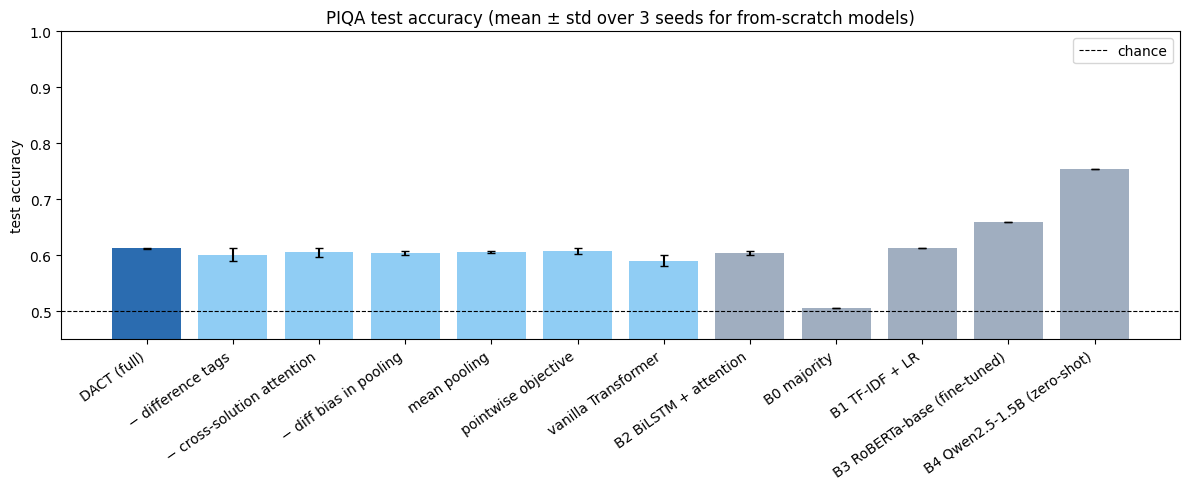

In [ ]:
order = ["DACT (full)"] + list(ABLATIONS) + ["B2 BiLSTM + attention"] + list(BASE)
R = RESULTS.set_index("model").loc[order]
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2b6cb0"] + ["#90cdf4"] * len(ABLATIONS) + ["#a0aec0"] * (1 + len(BASE))
ax.bar(range(len(R)), R["test acc"], yerr=R["test std"].fillna(0), color=colors, capsize=3)
ax.axhline(0.5, ls="--", c="k", lw=0.8, label="chance")
ax.set_xticks(range(len(R))); ax.set_xticklabels(R.index, rotation=35, ha="right")
ax.set_ylabel("test accuracy"); ax.set_ylim(0.45, 1.0); ax.legend()
ax.set_title("PIQA test accuracy (mean ± std over 3 seeds for from-scratch models)")
plt.tight_layout(); plt.savefig(os.path.join(CFG.out_dir, "results", "test_accuracy.png"), dpi=120); plt.show()

### Interpretation required after execution
Use the newly produced tables and retained predictions to write the analysis. Do not transfer numerical
claims from the historical study or interpret smoke metrics as generalisation results. Historical audit:
full DACT did not outperform every single-component ablation on test; avoid causal claims from weak
differences. CI columns concern representative seeds, while error bars show across-seed sample SD.
The original 12-way Holm correction is exploratory; report the comparison family used in this run.

## 3.3 Qualitative analysis of attention
We analyse the best-validation-seed checkpoint of the full DACT. For each selected test item the figure shows:
1. **top row**: the difference-guided pooling weights over each option's tokens (the vector the scorer sees);
2. **bottom-left**: contrastive cross-solution attention from option-1 tokens (rows) to option-2 tokens (columns), averaged over heads;
3. **bottom-right**: last-encoder-layer attention from each option's tokens to the goal tokens.

Tokens that differ between the two options are shown in **bold red**. Cases: the two most confident correct predictions, the two most confident errors, and the most uncertain item.

In [ ]:
best_run = max(EXP["DACT (full)"]["runs"], key=lambda r: r["val_acc"])
DACT_BEST = DACT(BEST_CFG, DATA["vocab_size"]).to(DEVICE)
DACT_BEST.load_state_dict(torch.load(best_run["ckpt"], map_location=DEVICE))
DACT_BEST.eval()
tp = EXP["DACT (full)"]["test_preds"]
CASES = select_cases(tp["pred"], tp["prob"], tp["label"], k=2)
print(CASES)
os.makedirs(os.path.join(CFG.out_dir, "figures"), exist_ok=True)

{'confident_correct': [126, 877], 'confident_wrong': [551, 615], 'uncertain': [1293, 1433]}


--- confident_correct | test item 126 | gold = option 1
  goal: How can I get more use out of my utility knife?
  sol1: When the blade in your utility knife gets dull, it’s usually only the point and the first 1/4 in. or so that’s bad and you can get additional life from your blade by snapping off the point with a pliers (wear safety glasses) it won’t cut quite as well as a fresh blade, but a lot better than the dull one.
  sol2: When the blade in your utility knife gets dull, it’s usually only the point and the first 1/4 in. or so that’s bad and you can get additional life from your blade by snapping off the point with a bare finger (wear safety glasses) it won’t cut quite as well as a fresh blade, but a lot better than the dull one.


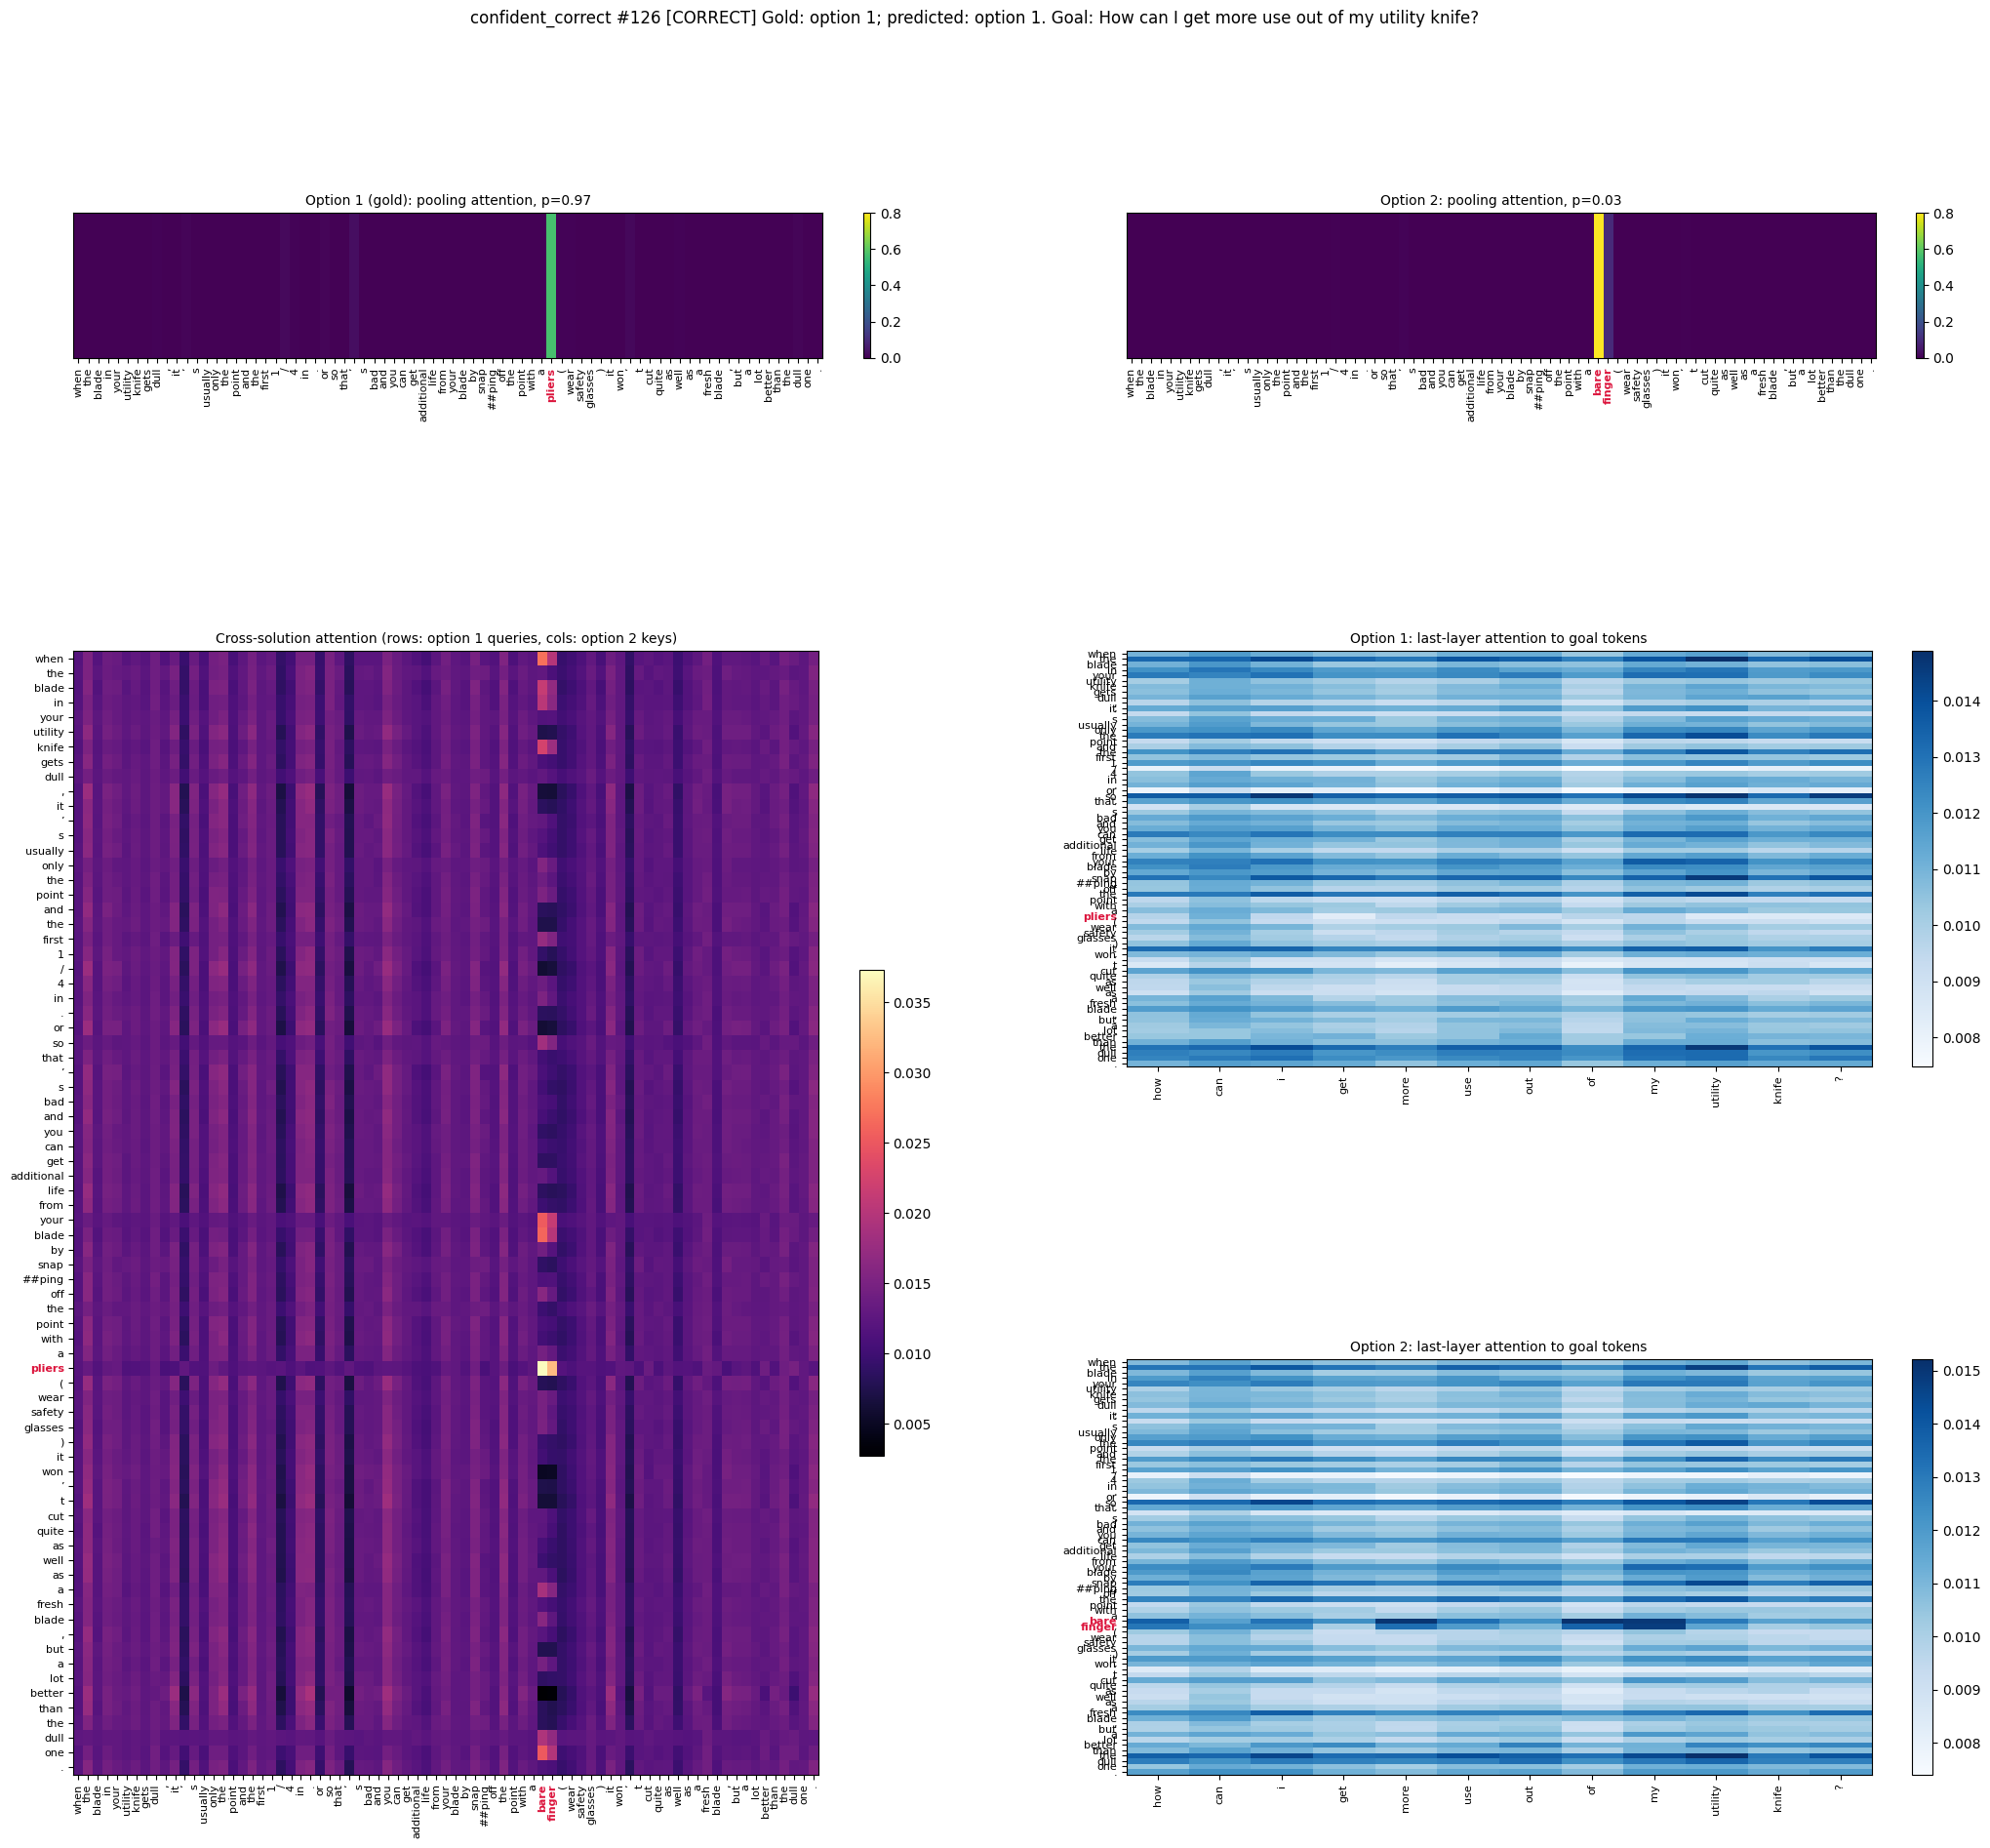

--- confident_correct | test item 877 | gold = option 2
  goal: how do you buckle down on something?
  sol1: leave it alone.
  sol2: concentrate on nothing else.


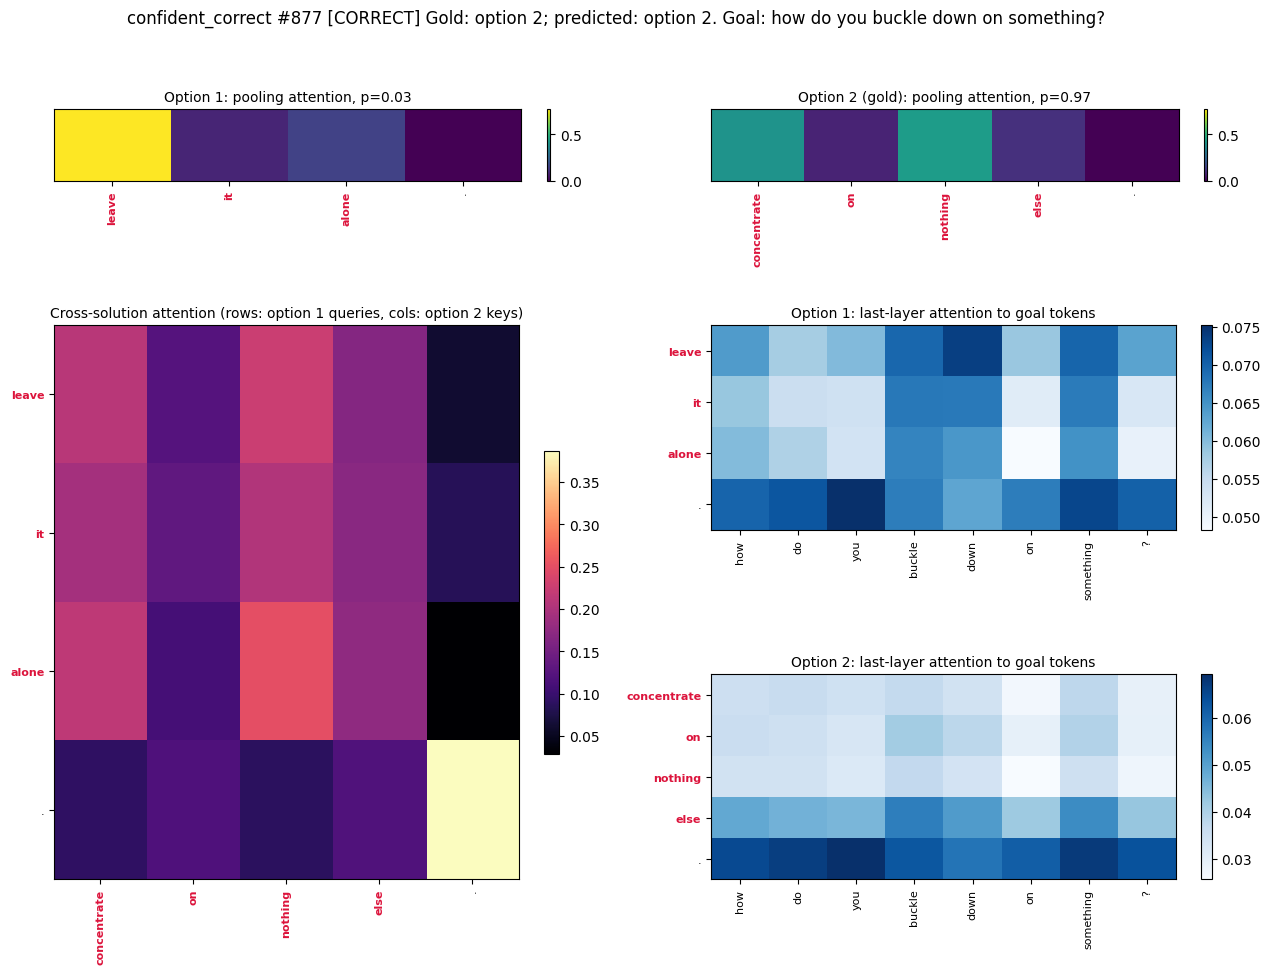

--- confident_wrong | test item 551 | gold = option 2
  goal: How to remove a stuck light bulb.
  sol1: Press the center of a foot-long strip of duct tape onto the middle of the bulb. Fold each loose end in half so it sticks onto itself. Gripping each end between your thumb and index finger, give a clockwise twist to loosen the bulb.
  sol2: Press the center of a foot-long strip of duct tape onto the middle of the bulb. Fold each loose end in half so it sticks onto itself. Gripping each end between your thumb and index finger, give a counterclockwise twist to loosen the bulb.


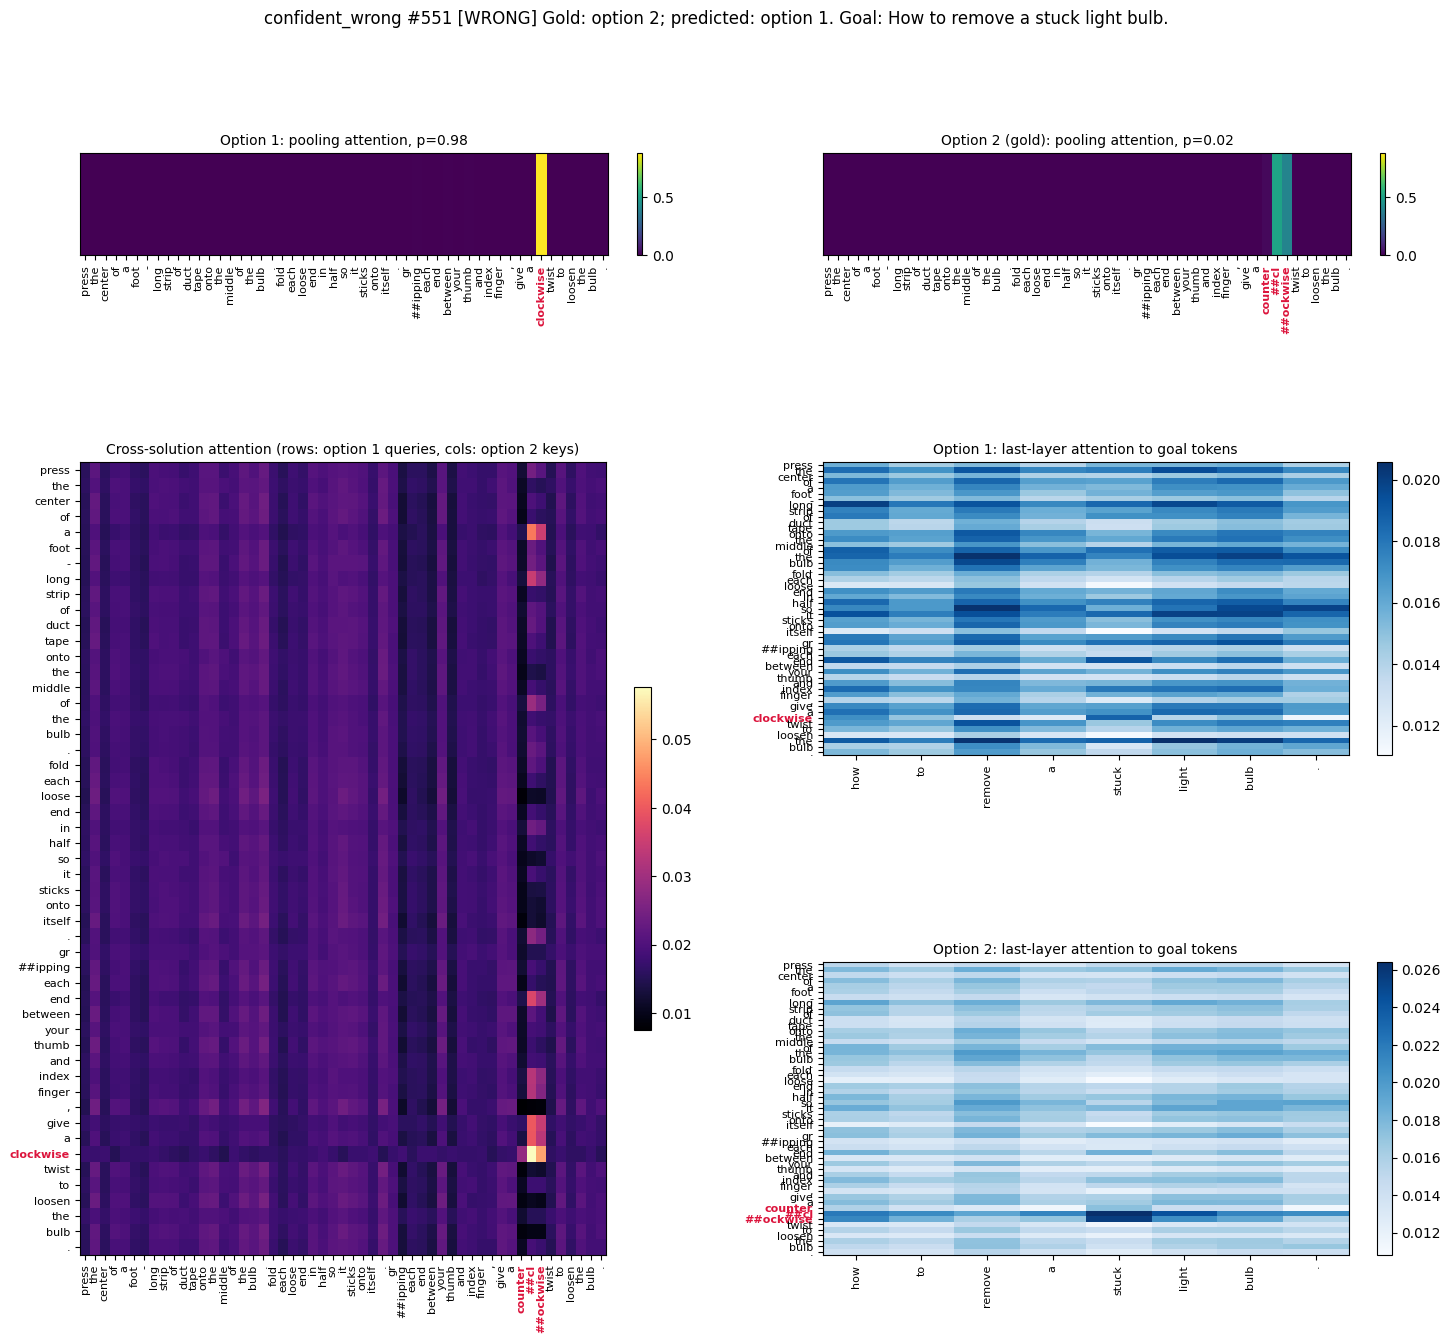

--- confident_wrong | test item 615 | gold = option 2
  goal: how do you check your credit score?
  sol1: call a credit card company.
  sol2: go to credit karma.com. type in all your information and create an account. then you can check your score whenever you want.


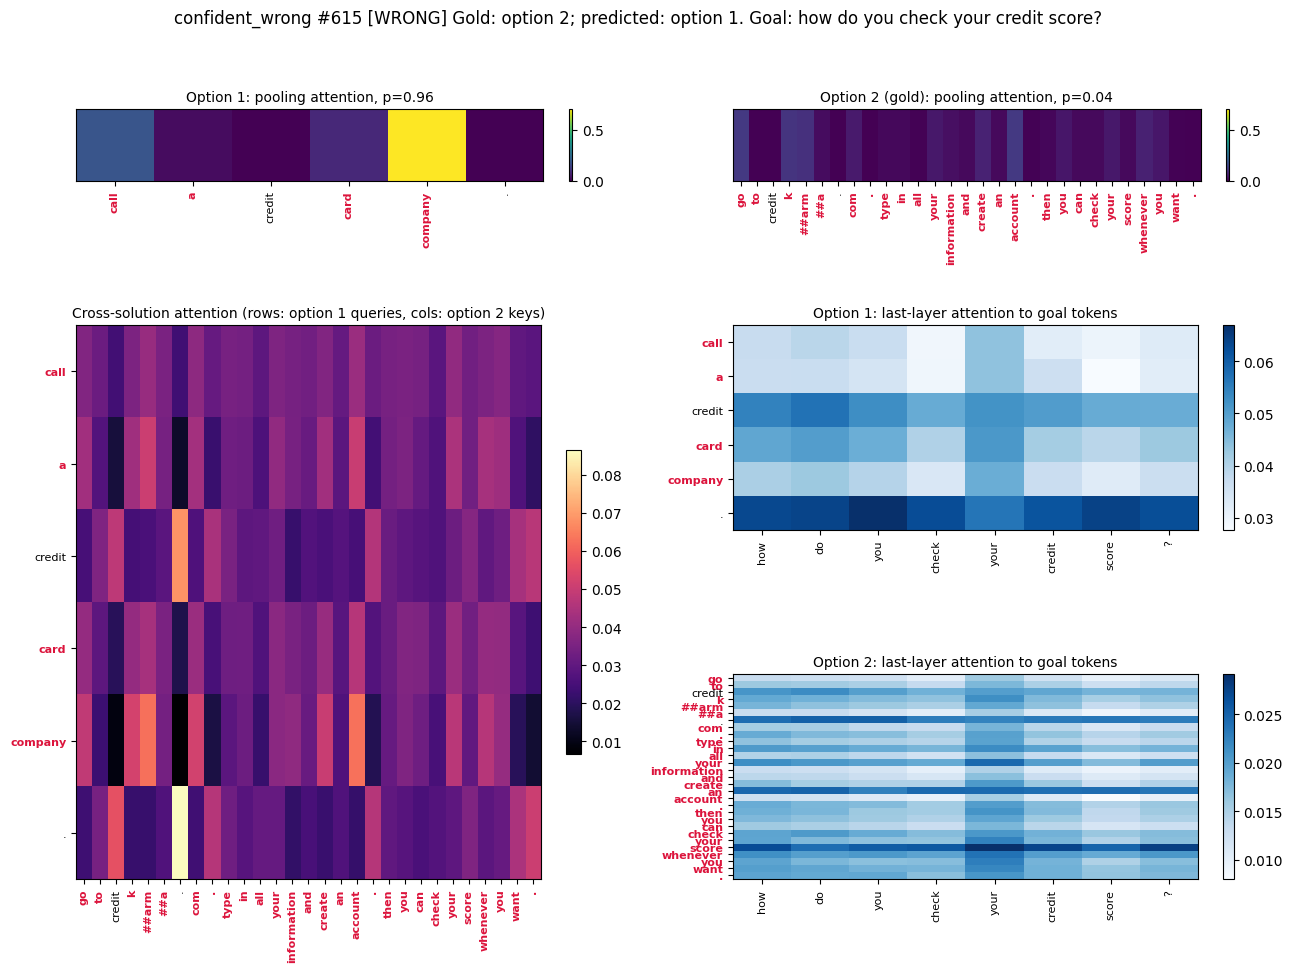

In [ ]:
for kind in ("confident_correct", "confident_wrong"):
    for i in CASES[kind]:
        r = DATA["test"][i]
        print(f"--- {kind} | test item {i} | gold = option {r['label'] + 1}\n  goal: {r['goal']}\n  sol1: {r['sol1']}\n  sol2: {r['sol2']}")
        plot_attention_case(DACT_BEST, r, DATA["tok"], BEST_CFG, DEVICE, title=f"{kind} #{i}",
                            save_path=os.path.join(CFG.out_dir, "figures", f"{kind}_{i}.png"))

--- uncertain | test item 1293 | gold = option 2
  goal: How do you ship live aquatic snails in the mail?
  sol1: To ship live aquatic snails in the mail, first make sure to research the laws, many gastropod species are classified as Plant Pests, and so are restricted from interstate travel in the US by USDA APHIS. Then, wrap snails in a piece of damp paper towel, fold it loosely around and tuck the snail into a ziplock baggie. Insulate the box with sytrofoam and packing peanuts. Add a heat or ice pack for mild weather.
  sol2: To ship live aquatic snails in the mail, first make sure to research the laws, many gastropod species are classified as Plant Pests, and so are restricted from interstate travel in the US by USDA APHIS. Then, wrap snails in a piece of damp paper towel, fold it loosely around and tuck the snail into a ziplock baggie. Insulate the box with sytrofoam and packing peanuts. Add a heat or ice pack for extreme weather.


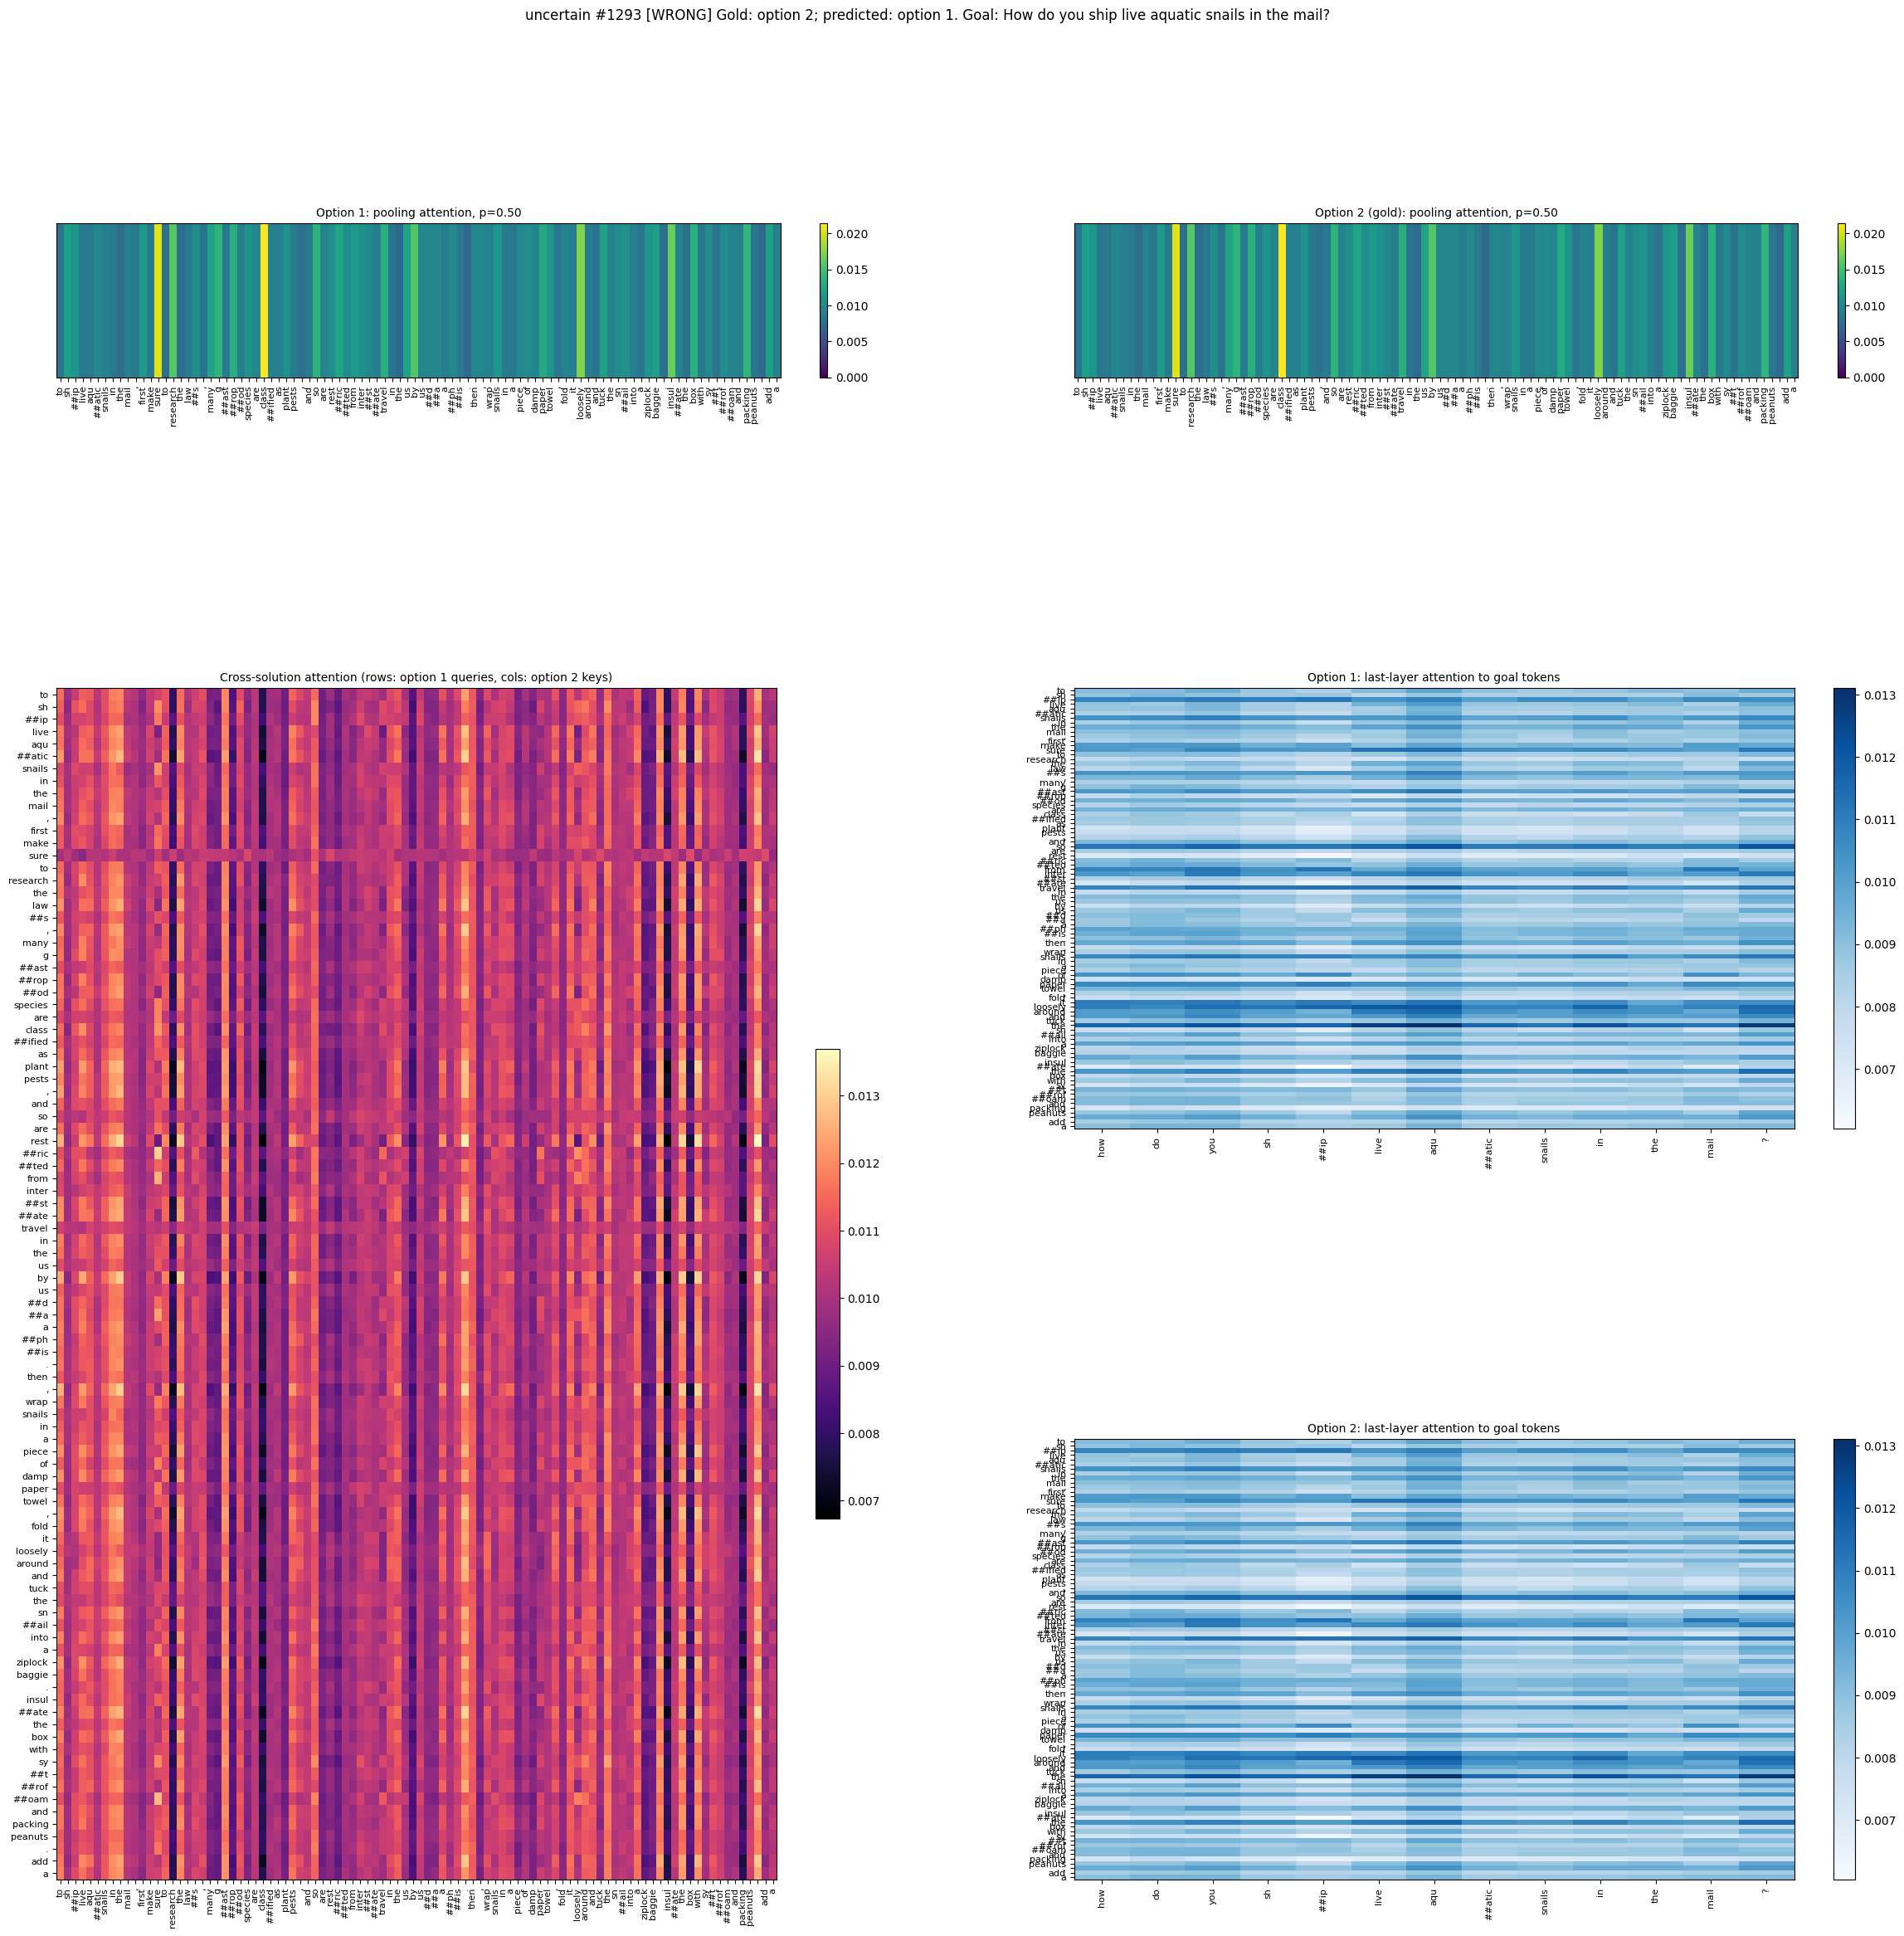

In [ ]:
i = CASES["uncertain"][0]
r = DATA["test"][i]
print(f"--- uncertain | test item {i} | gold = option {r['label'] + 1}\n  goal: {r['goal']}\n  sol1: {r['sol1']}\n  sol2: {r['sol2']}")
_ = plot_attention_case(DACT_BEST, r, DATA["tok"], BEST_CFG, DEVICE, title=f"uncertain #{i}",
                        save_path=os.path.join(CFG.out_dir, "figures", f"uncertain_{i}.png"))

### Does attention focus on the differing tokens, and does that relate to correctness?
For every test item we measure the share of pooling attention that falls on difference-tagged tokens and compare it with the share those tokens would get under uniform attention, separately for correct and wrong predictions.

learned pooling tag bias [other, shared, diff]: [ 0.    -0.025  1.025]
mean attention mass on differing tokens: 0.834 (uniform-attention reference 0.248)
  correct predictions: 0.833 | wrong predictions: 0.836
  Mann-Whitney U (correct vs wrong): p = 0.3907


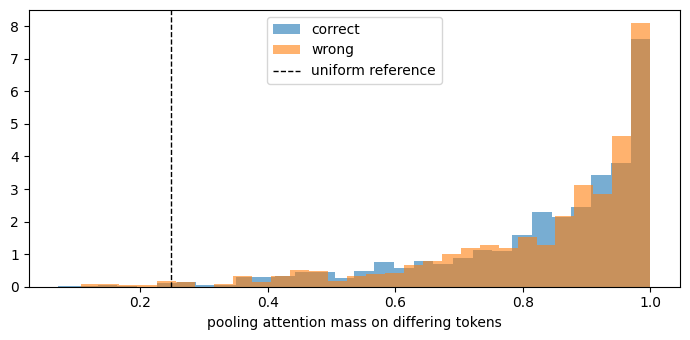

In [ ]:
from scipy.stats import mannwhitneyu
test_loader = make_loader(DATA["test_ds"], BEST_CFG, False, DEVICE)
mass, correct = diff_attention_mass(DACT_BEST, test_loader, DEVICE)
uniform = diff_token_share(test_loader)
print(f"learned pooling tag bias [other, shared, diff]: {DACT_BEST.pool.tag_bias.detach().cpu().numpy().round(3)}")
print(f"mean attention mass on differing tokens: {mass.mean():.3f} (uniform-attention reference {uniform.mean():.3f})")
print(f"  correct predictions: {mass[correct].mean():.3f} | wrong predictions: {mass[~correct].mean():.3f}")
print("  Mann-Whitney U (correct vs wrong): p = %.4g" % mannwhitneyu(mass[correct], mass[~correct]).pvalue)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(mass[correct], bins=30, alpha=0.6, density=True, label="correct")
ax.hist(mass[~correct], bins=30, alpha=0.6, density=True, label="wrong")
ax.axvline(uniform.mean(), c="k", ls="--", lw=1, label="uniform reference")
ax.set_xlabel("pooling attention mass on differing tokens"); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CFG.out_dir, "figures", "diff_attention_mass.png"), dpi=120); plt.show()

### Interpretation required after execution
Inspect these actual figures. Include correct and failed cases, expected answers, predicted answers and
confidence. Attention slices are not renormalised; cross slices exclude the CLS sink. The positive
difference pooling bias is present before learning. Maps describe behaviour and do not prove causal
reasoning (https://aclanthology.org/N19-1357/). Do not copy historical case numbers or explanations into
a new run. Prefix truncation, directional historical alignment and rare vocabulary remain limitations.

In [ ]:
import shutil
if not SMOKE and os.path.isdir("/content/drive/MyDrive"):
    dst = "/content/drive/MyDrive/Group69/" + os.path.basename(CFG.out_dir)
    shutil.copytree(CFG.out_dir,dst,dirs_exist_ok=False)
    print("Copied all evidence including checkpoints:",dst)
print("Retain/download:",CFG.out_dir)

Retain/download: experiments/completed/outputs_reproduction_20261001_161337
